# ECG Arrhythmia Classification — CS4082 Project
## PhysioNet Challenge 2017 Dataset

**Dataset:** [PhysioNet Challenge 2017](https://physionet.org/content/challenge-2017/1.0.0/)  
**Task:** Classify short single-lead ECG recordings into 4 classes:  
- **N** → Normal sinus rhythm  
- **A** → Atrial Fibrillation (AF)  
- **O** → Other / abnormal rhythm  
- **~** → Too noisy to classify  

**Pipeline overview:**  
`Setup → EDA → Preprocessing → Adversarial Injection → Baseline Models → Hyperparameter Tuning → Class Imbalance → Feature Selection → Ensemble → Final Evaluation`


---
#  0. Setup — Install Libraries & Mount Drive

>  We need `wfdb` to read the PhysioNet `.mat`/`.hea` binary ECG format,  
`imbalanced-learn` for SMOTE, and `xgboost` for gradient boosting.  
All other libraries (sklearn, pandas, numpy, matplotlib, seaborn) come pre-installed in Colab.

In [ ]:
!pip install wfdb imbalanced-learn xgboost -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


>  We upload the dataset zip directly to Colab. The archive contains:
- `.mat` files — raw ECG signal (binary format)  
- `.hea` files — metadata (sampling rate, lead name)  
- `REFERENCE.csv` — the label for each recording

In [ ]:
import zipfile
import shutil
import os


data_dir = "/content/MLdataset"

# Extract zip from Google Drive into data_dir
zip_path = "/content/drive/MyDrive/training2017.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

# Paths using SAME naming style
ref_original = "/content/drive/MyDrive/REFERENCE-v3.csv"
ref_target = os.path.join(data_dir, "REFERENCE.csv")

# Copy instead of rename
if os.path.exists(ref_original) and not os.path.exists(ref_target):
    shutil.copy(ref_original, ref_target)

print("Data directory ready:", data_dir)

Data directory ready: /content/MLdataset


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wfdb
from scipy.signal import resample
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, VotingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [ ]:
labels = pd.read_csv(os.path.join(data_dir, "REFERENCE.csv"), header=None)

---
#  1.Exploratory Data Analysis (EDA)


> Before building any model, we need to understand the data structure.  
EDA reveals class imbalance, signal variability, and noise — all critical for choosing the right modeling strategy.  
Skipping EDA leads to surprises during training.

## 1.1 Visualize Sample ECG Signals





>  Explore Dataset

In [ ]:
# 1. View the columns
print("Columns:", labels.columns.tolist())

# 2. View data info (types and null counts)
print("\nData Info:")
print(labels.info())

# 3. View the shape (Number of records)
print("\nShape:", labels.shape)

# 4. View the first few rows
print("\nFirst 5 rows:")
print(labels.head())

Columns: [0, 1]

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 8528 entries, 0 to 8527
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       8528 non-null   str  
 1   1       8528 non-null   str  
dtypes: str(2)
memory usage: 191.7 KB
None

Shape: (8528, 2)

First 5 rows:
        0  1
0  A00001  N
1  A00002  N
2  A00003  N
3  A00004  A
4  A00005  A


In [ ]:
# Rename columns
labels.columns = ['record_id', 'label']

print("Labels loaded successfully")
print(labels.head())

Labels loaded successfully
  record_id label
0    A00001     N
1    A00002     N
2    A00003     N
3    A00004     A
4    A00005     A


In [ ]:
record_name = "A00001"
data = "/content/MLdataset/training2017"

# load ECG signal
record = wfdb.rdrecord(os.path.join(data, record_name))
signal = record.p_signal

# get label (assuming labels already loaded earlier)
label = labels.loc[labels["record_id"] == record_name, "label"].values[0]

print("Record:", record_name)
print("Signal shape:", signal.shape)
print("Label:", label)
print("First 5 values:")
print(signal[:5])

Record: A00001
Signal shape: (9000, 1)
Label: N
First 5 values:
[[-0.127]
 [-0.162]
 [-0.197]
 [-0.229]
 [-0.245]]


> Plot the ECG waveform

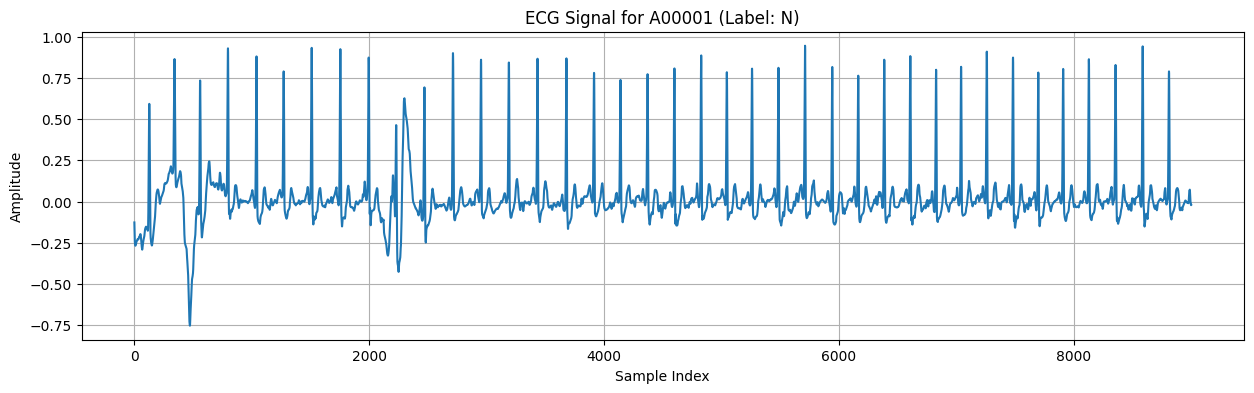

In [ ]:
plt.figure(figsize=(15, 4))
plt.plot(signal)
plt.title(f"ECG Signal for {record_name} (Label: {label})")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

> Plot multiple ECG waveform

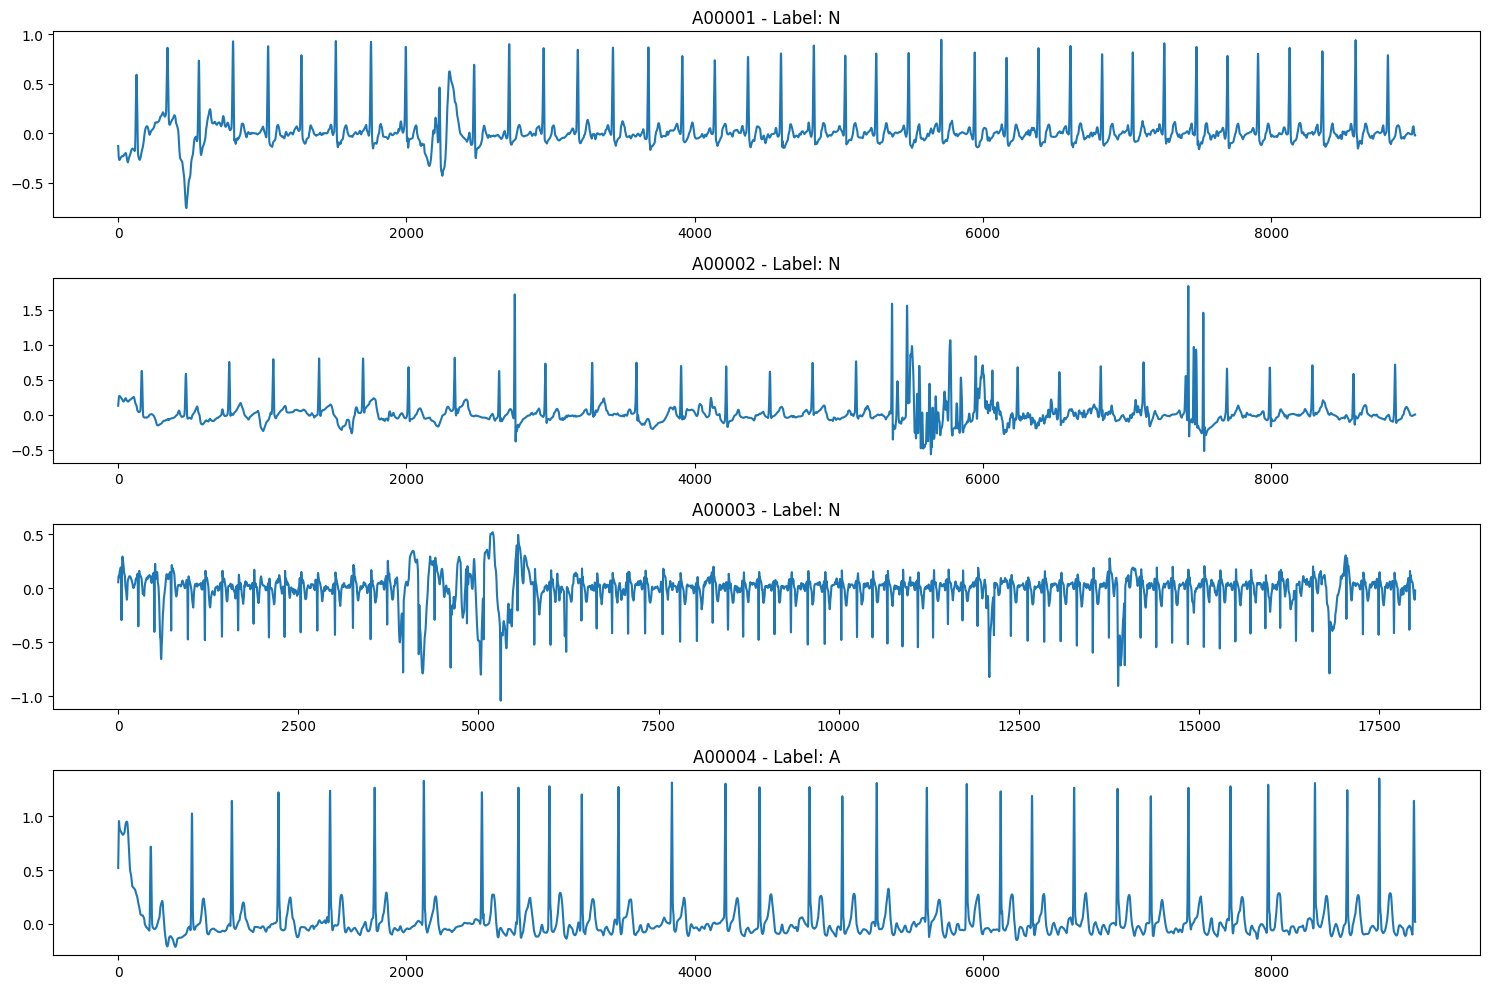

In [ ]:
import random

sample_records = ["A00001", "A00002", "A00003", "A00004"]

plt.figure(figsize=(15, 10))

for i, rec in enumerate(sample_records):
    record = wfdb.rdrecord(os.path.join(data, rec))
    signal = record.p_signal

    label = labels.loc[labels["record_id"] == rec, "label"].values[0]

    plt.subplot(len(sample_records), 1, i+1)
    plt.plot(signal)
    plt.title(f"{rec} - Label: {label}")

plt.tight_layout()
plt.show()

## 1.2 Class Distribution

Class Distribution:
 label
N    5076
O    2415
A     758
~     279
Name: count, dtype: int64


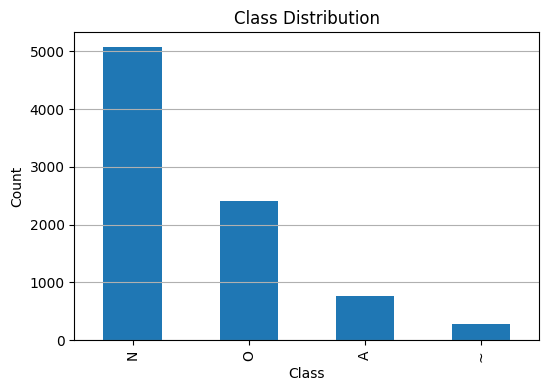

In [ ]:
# count labels
class_counts = labels["label"].value_counts()

print("Class Distribution:\n", class_counts)

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

> The dataset exhibits significant class imbalance, with the Normal class dominating the distribution, while Atrial Fibrillation and noisy signals are underrepresented. This imbalance can bias model performance toward the majority class.

## 1.3 Missing Values Analysis




In [ ]:
missing_count = 0
for rec in labels['record_id']:
    record = wfdb.rdrecord(os.path.join(data, rec))
    if np.isnan(record.p_signal).any():
        missing_count += 1

print(f"Records with missing values: {missing_count} / {len(labels)}")

Records with missing values: 0 / 8528


> No missing values were detected in the ECG signals, indicating that the dataset is clean and does not require imputation.

## 1.4 Duplicate Record Check

In [ ]:
from collections import defaultdict

# 1. Check Metadata IDs
duplicate_ids = labels[labels.duplicated(subset="record_id", keep=False)]
if len(duplicate_ids) == 0:
    print("No duplicate record IDs found.")
else:
    print(f"Found {len(duplicate_ids)} duplicate IDs.")

# 2. Check Signal Content (All records)
print("\nChecking all signals for duplicate content...")
signal_hashes = defaultdict(list)

for rec in labels["record_id"]: # Checked all records now
    try:
        record = wfdb.rdrecord(os.path.join(data, rec))
        # Using 1000 samples is a good "fingerprint"
        sig = record.p_signal.flatten()[:1000]
        sig_hash = hash(sig.tobytes())
        signal_hashes[sig_hash].append(rec)
    except Exception as e:
        print(f"Could not read {rec}: {e}")

true_dupes = {h: recs for h, recs in signal_hashes.items() if len(recs) > 1}

if len(true_dupes) == 0:
    print("No identical signal content found.")
else:
    print(f"Found {len(true_dupes)} groups of identical signals:")
    for h, recs in true_dupes.items():
        print(f"  Signals {recs} are identical.")

No duplicate record IDs found.

Checking all signals for duplicate content...
Found 2 groups of identical signals:
  Signals ['A00227', 'A01176'] are identical.
  Signals ['A02656', 'A03123'] are identical.


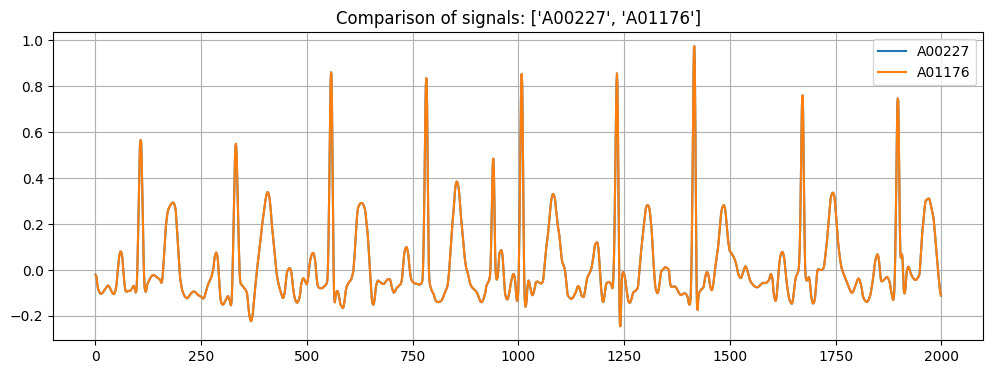

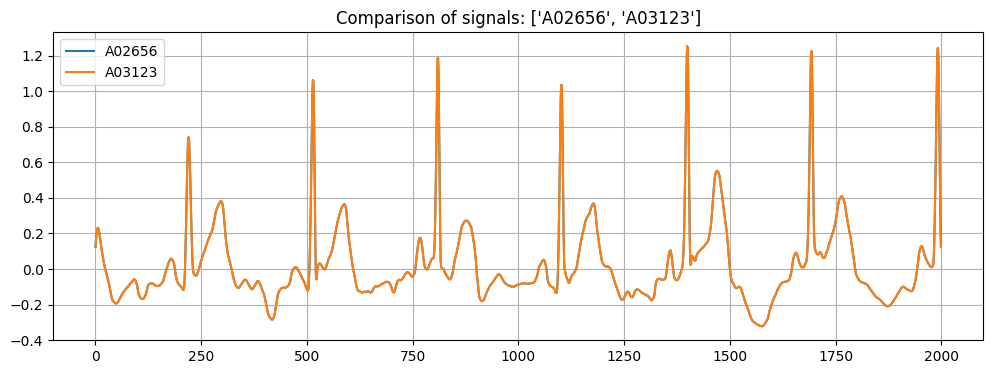

In [ ]:
duplicate_groups = [
    ['A00227', 'A01176'],
    ['A02656', 'A03123']
]

for group in duplicate_groups:
    plt.figure(figsize=(12, 4))

    for rec in group:
        record = wfdb.rdrecord(os.path.join(data, rec))
        sig = record.p_signal[:, 0]  # single lead

        plt.plot(sig[:2000], label=rec)  # zoom first 2000 samples

    plt.title(f"Comparison of signals: {group}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# List of duplicate IDs to remove (choosing one from each pair)
to_remove = ['A01176', 'A03123']

# Filter the labels dataframe to exclude these
labels = labels[~labels['record_id'].isin(to_remove)]

print(f"Removed {len(to_remove)} duplicate signals. New total records: {len(labels)}")

Removed 2 duplicate signals. New total records: 8526


## 1.5 Signal Length Analysis

>  ECG recordings in this dataset have variable lengths (different recording durations).  
ML models require fixed-size inputs, so we must decide on a target length for resampling.  


Min length : 2714 samples
Max length : 18286 samples
Mean length: 9749 samples
Median     : 9000 samples


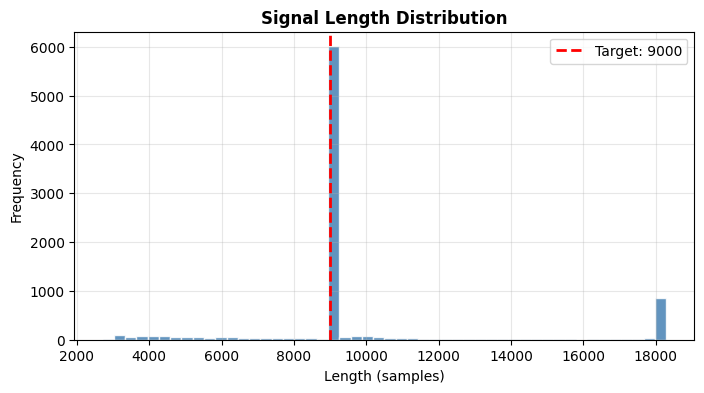

In [ ]:
lengths = []
for rec in labels['record_id']:
    record = wfdb.rdrecord(os.path.join(data, rec))
    lengths.append(record.p_signal.shape[0])

lengths = np.array(lengths)
print(f"Min length : {lengths.min()} samples")
print(f"Max length : {lengths.max()} samples")
print(f"Mean length: {lengths.mean():.0f} samples")
print(f"Median     : {np.median(lengths):.0f} samples")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(9000, color='red', linestyle='--', linewidth=2, label='Target: 9000')
plt.title("Signal Length Distribution", fontweight='bold')
plt.xlabel("Length (samples)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

> Most signals are around 9000 samples, so we use 9000 as the fixed length for all signals.

## 1.6 Outlier Analysis (Amplitude Boxplot)

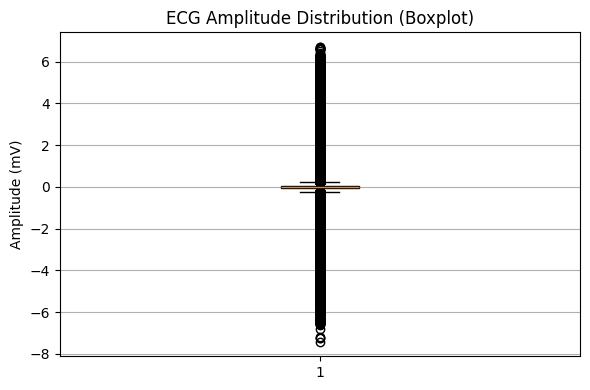

In [ ]:
all_values = []
for rec in labels["record_id"][:500]:
    record = wfdb.rdrecord(os.path.join(data, rec))
    all_values.extend(record.p_signal.flatten())

all_values = np.array(all_values)

plt.figure(figsize=(6, 4))
plt.boxplot(all_values, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title("ECG Amplitude Distribution (Boxplot)")
plt.ylabel("Amplitude (mV)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

>The amplitude distribution shows the presence of extreme values corresponding to ECG peaks (QRS complexes), which are expected physiological features rather than true anomalies.

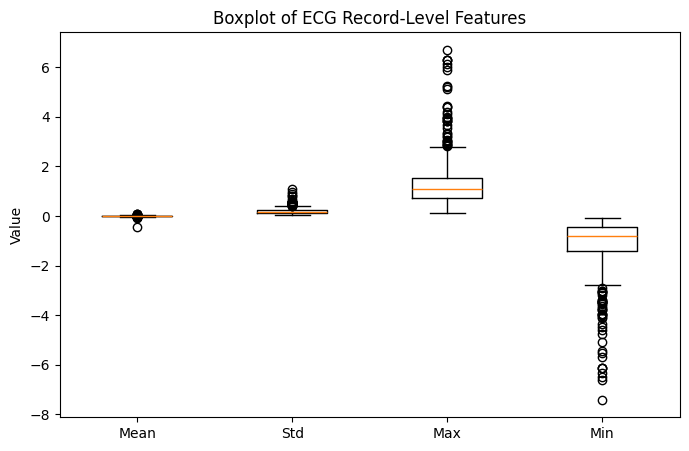

In [ ]:
record_features = []

for rec in labels["record_id"][:500]:
    record = wfdb.rdrecord(os.path.join(data, rec))
    sig = record.p_signal.flatten()
    record_features.append([
        np.mean(sig),
        np.std(sig),
        np.max(sig),
        np.min(sig)
    ])

record_features = np.array(record_features)

plt.figure(figsize=(8,5))
plt.boxplot(record_features, tick_labels=["Mean", "Std", "Max", "Min"])
plt.title("Boxplot of ECG Record-Level Features")
plt.ylabel("Value")
plt.show()

> To perform a more meaningful outlier analysis, record-level features were extracted from each ECG signal, including mean, standard deviation, maximum, and minimum amplitude. The resulting boxplots show that the mean values are centered near zero with low variability, indicating consistent signal baselines across recordings. However, the maximum and minimum amplitude features exhibit a wider spread with several extreme values. These extremes likely correspond to physiological peaks such as QRS complexes or potential signal noise rather than true anomalies. Therefore, while variability exists across recordings, these values should not be automatically treated as outliers requiring removal.


## 1.7 Signal Heatmap (Multi-Record View)

> A heatmap overlays multiple signals to visually compare their time-series patterns.  
Color intensity = amplitude. Vertical bands = heartbeat peaks.  
This helps us see how much variability exists across recordings.

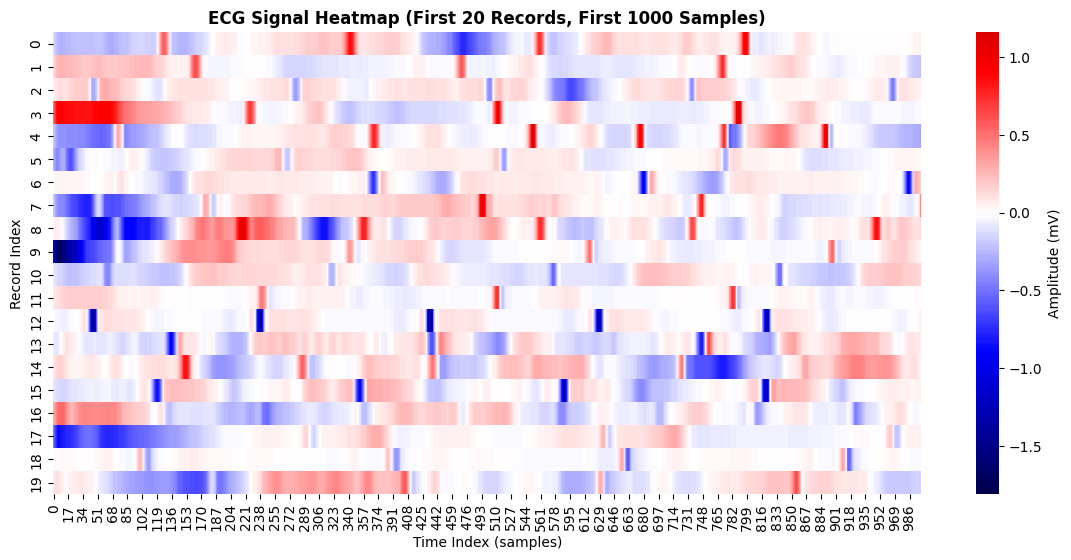

In [ ]:
sample_signals = []
for rec in labels['record_id'][:20]:
    record = wfdb.rdrecord(os.path.join(data, rec))
    sig = record.p_signal[:, 0][:1000]
    sample_signals.append(sig)

sample_signals = np.array(sample_signals)

plt.figure(figsize=(14, 6))
sns.heatmap(sample_signals, cmap='seismic', center=0, cbar_kws={'label': 'Amplitude (mV)'})
plt.title("ECG Signal Heatmap (First 20 Records, First 1000 Samples)", fontweight='bold')
plt.xlabel("Time Index (samples)")
plt.ylabel("Record Index")
plt.show()

>The heatmap highlights variability in ECG signals across different records, with visible differences in amplitude patterns over time.This confirms that the dataset contains diverse signal patterns suitable for classification tasks.

---
# 2.Preprocessing Pipeline

> **Why preprocessing?**  
Raw ECG signals cannot be fed directly to ML classifiers because:  
1. Variable lengths → need fixed-size vectors  
2. String labels ('N','A','O','~') → need integers  
3. Different signal amplitudes → need normalization  
4. All data in one pool → need separate train/val/test sets

## 2.1 Build Feature Matrix (X) and Labels (y) — Signal Resampling

> All models need the same input dimensionality. We resample every signal to 9000 points  
(~30 seconds at 300Hz) using scipy's `resample()` which uses Fourier-based resampling  
(preserves frequency content better than simple truncation/padding).

In [ ]:
TARGET_LENGTH = 9000

X = []
y = []

print("Building dataset..")
for i, rec in enumerate(labels['record_id']):
    record = wfdb.rdrecord(os.path.join(data, rec))
    sig = record.p_signal[:, 0]          # single lead
    sig = resample(sig, TARGET_LENGTH)   # Fourier resample → fixed length
    X.append(sig)
    y.append(labels.loc[labels['record_id'] == rec, 'label'].values[0])
    if (i+1) % 1000 == 0:
        print(f"  Processed {i+1}/{len(labels)} records")

X = np.array(X)
y = np.array(y)

print(f"\nX shape: {X.shape}  (records × time points)")
print(f"y shape: {y.shape}")

Building dataset..
  Processed 1000/8526 records
  Processed 2000/8526 records
  Processed 3000/8526 records
  Processed 4000/8526 records
  Processed 5000/8526 records
  Processed 6000/8526 records
  Processed 7000/8526 records
  Processed 8000/8526 records

X shape: (8526, 9000)  (records × time points)
y shape: (8526,)


## 2.2 Label Encoding

In [ ]:
# Define the human-readable names for the abbreviations
class_names = {
    'N': 'Normal',
    'A': 'Atrial Fibrillation',
    'O': 'Other rhythm',
    '~': 'Noise'
}

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Class mapping:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  '{cls}' ({class_names.get(cls, cls)}) → {enc}")

Class mapping:
  'A' (Atrial Fibrillation) → 0
  'N' (Normal) → 1
  'O' (Other rhythm) → 2
  '~' (Noise) → 3


## 2.3 Train / Validation / Test Split (70% / 15% / 15%)

>With class imbalance, a random split might put all Noise (~) samples in one partition.  
Stratified splitting ensures every partition has the same class proportions.  
We also use a fixed `random_state=42` for reproducibility.

In [ ]:
# 70% train, 15% validation, 15% test — stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val set     : {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test set    : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

# Verify class balance in each split
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    vals, cnts = np.unique(y_split, return_counts=True)
    dist = {le.classes_[v]: c for v, c in zip(vals, cnts)}
    print(f"  {split_name}: {dist}")

Train set   : 5968 samples (70%)
Val set     : 1279 samples (15%)
Test set    : 1279 samples (15%)
  Train: {np.str_('A'): np.int64(531), np.str_('N'): np.int64(3552), np.str_('O'): np.int64(1690), np.str_('~'): np.int64(195)}
  Val: {np.str_('A'): np.int64(114), np.str_('N'): np.int64(761), np.str_('O'): np.int64(362), np.str_('~'): np.int64(42)}
  Test: {np.str_('A'): np.int64(113), np.str_('N'): np.int64(761), np.str_('O'): np.int64(363), np.str_('~'): np.int64(42)}


## 2.4 Feature Scaling (StandardScaler)

> ECG amplitudes vary across patients and recording devices.  
StandardScaler transforms each feature to mean=0, std=1.  
**Critical rule:** Fit ONLY on training data, then apply to val/test.  
Fitting on all data would cause data leakage (test info contaminating training).

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_val_scaled   = scaler.transform(X_val)          # transform only (no fit)
X_test_scaled  = scaler.transform(X_test)         # transform only (no fit)

print("   Scaling applied — training mean ≈ 0, std ≈ 1")
print(f"  Train mean (first 3 features): {X_train_scaled[:, :3].mean(axis=0).round(4)}")
print(f"  Train std  (first 3 features): {X_train_scaled[:, :3].std(axis=0).round(4)}")

   Scaling applied — training mean ≈ 0, std ≈ 1
  Train mean (first 3 features): [-0. -0.  0.]
  Train std  (first 3 features): [1. 1. 1.]


---
#  3.Adversarial Condition Injection

> **Why inject adversarial conditions?**  
Real-world clinical data is imperfect. Doctors mislabel records, equipment drift causes signal shifts,  
and some classes are rarely seen during collection. Injecting these conditions tests whether our models  
are robust or fragile. This is what makes our project unique — we don't just evaluate on clean data.

> **Why label noise?**  
In real hospitals, ECG annotation is done by cardiologists who sometimes disagree.  
We simulate annotation errors by randomly flipping 10% of training labels to a different class.  
**Applied only to training data** — val/test remain clean (like a real deployment scenario).

In [ ]:
def inject_label_noise(y, noise_ratio=0.10, seed=42):
    """Flip `noise_ratio` fraction of training labels to a random different class."""
    np.random.seed(seed)
    y_noisy = y.copy()
    n_noisy = int(noise_ratio * len(y))
    indices = np.random.choice(len(y), n_noisy, replace=False)

    all_classes = np.unique(y)
    for idx in indices:
        other = [c for c in all_classes if c != y_noisy[idx]]
        y_noisy[idx] = np.random.choice(other)

    changed = np.sum(y != y_noisy)
    print(f"Label noise injected: {changed} labels flipped ({changed/len(y)*100:.1f}%)")
    return y_noisy

y_train_noisy = inject_label_noise(y_train, noise_ratio=0.10)

Label noise injected: 596 labels flipped (10.0%)


---
#  4.Baseline Models — Train & Evaluate All Classifiers

> **Why train all these models?**  
Different classifiers make different assumptions about the data.  
Before spending time tuning, we compare all of them on the same data to identify the top 2–3 performers.  
We train two versions of each: one on clean labels, one on noisy labels — to measure noise robustness.

> **Evaluation metrics used:**
- **Accuracy** — overall correct predictions (misleading with imbalanced data alone)  
- **Precision** — of all predicted positives, how many were correct (avoids false alarms)  
- **Recall** — of all actual positives, how many were found (avoids missing cases)  
- **F1-score** — harmonic mean of Precision and Recall (best single metric for imbalanced data)  
- **AUC-ROC** — area under the ROC curve, measures discrimination ability across thresholds

## 4.0 Helper Functions

In [ ]:
def evaluate_model(name, y_true, y_pred, y_proba, classes=[0,1,2,3]):
    """Compute and print all metrics. Return as dict."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    y_bin = label_binarize(y_true, classes=classes)
    auc   = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='weighted')

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
          target_names=[class_names[c] for c in le.classes_], zero_division=0))

    return {'name': name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'auc': auc}


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[class_names[c] for c in le.classes_])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_roc_curves(y_true, y_proba, title, classes=[0,1,2,3]):
    y_bin = label_binarize(y_true, classes=classes)
    colors = ['steelblue', 'tomato', 'seagreen', 'orange']
    plt.figure(figsize=(7, 5))
    for i, (cls, col) in enumerate(zip(le.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        auc_score = roc_auc_score(y_bin[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, color=col, label=f"{class_names[cls]} (AUC={auc_score:.3f})")
    plt.plot([0,1],[0,1],'k--', alpha=0.4)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


all_results = []
print("✅ Helper functions defined")

✅ Helper functions defined


> Helper functions were created to evaluate model performance using metrics such as accuracy, precision, recall, F1-score, and AUC-ROC, along with visualization tools like confusion matrices and ROC curves for deeper analysis.

## 4.2 Logistic Regression


  Logistic Regression (Clean)
  Accuracy : 0.4128
  Precision: 0.4579
  Recall   : 0.4128
  F1-score : 0.4319
  AUC-ROC  : 0.5041

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.11      0.19      0.14       114
             Normal       0.61      0.52      0.56       761
       Other rhythm       0.30      0.28      0.29       362
              Noise       0.09      0.19      0.12        42

           accuracy                           0.41      1279
          macro avg       0.28      0.30      0.28      1279
       weighted avg       0.46      0.41      0.43      1279



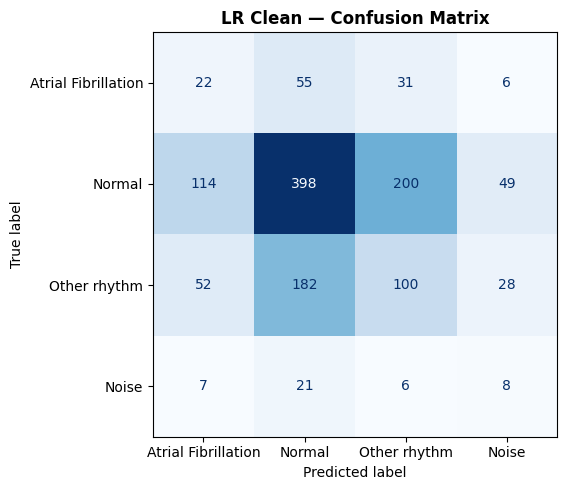

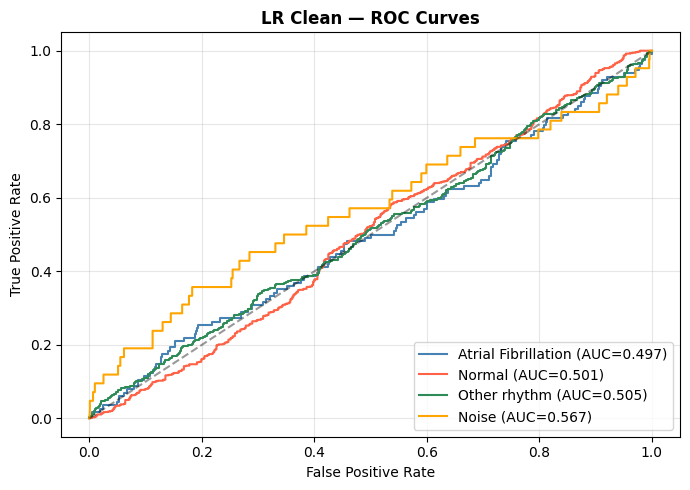


  Logistic Regression (Noisy)
  Accuracy : 0.3800
  Precision: 0.4664
  Recall   : 0.3800
  F1-score : 0.4137
  AUC-ROC  : 0.5008

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.10      0.19      0.13       114
             Normal       0.61      0.46      0.53       761
       Other rhythm       0.32      0.28      0.30       362
              Noise       0.06      0.21      0.09        42

           accuracy                           0.38      1279
          macro avg       0.27      0.29      0.26      1279
       weighted avg       0.47      0.38      0.41      1279



In [ ]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)

# Clean
lr_clean = clone(lr)
lr_clean.fit(X_train_scaled, y_train)

y_pred_lr = lr_clean.predict(X_val_scaled)
y_proba_lr = lr_clean.predict_proba(X_val_scaled)

r = evaluate_model('Logistic Regression (Clean)', y_val, y_pred_lr, y_proba_lr)
all_results.append(r)
plot_confusion_matrix(y_val, y_pred_lr, 'LR Clean — Confusion Matrix')
plot_roc_curves(y_val, y_proba_lr, 'LR Clean — ROC Curves')

# Noisy
lr_noisy = clone(lr)
lr_noisy.fit(X_train_scaled, y_train_noisy)

y_pred_lr_n = lr_noisy.predict(X_val_scaled)
y_proba_lr_n = lr_noisy.predict_proba(X_val_scaled)

r = evaluate_model('Logistic Regression (Noisy)', y_val, y_pred_lr_n, y_proba_lr_n)
all_results.append(r)

>Logistic Regression achieved relatively low accuracy (~41%) and failed to correctly classify minority classes. The confusion matrix shows a strong bias toward the majority class (Normal), with low recall for Atrial Fibrillation and poor performance on other classes.

>Additionally, AUC-ROC values close to 0.5 indicate that the model performs near random guessing. Label noise had minimal impact on performance, suggesting that the model is already limited in capturing meaningful patterns in the data.

## 4.3 Decision Tree


  Decision Tree (Clean)
  Accuracy : 0.5528
  Precision: 0.4505
  Recall   : 0.5528
  F1-score : 0.4739
  AUC-ROC  : 0.5152

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.07      0.02      0.03       114
             Normal       0.61      0.87      0.72       761
       Other rhythm       0.28      0.10      0.15       362
              Noise       0.15      0.07      0.10        42

           accuracy                           0.55      1279
          macro avg       0.28      0.27      0.25      1279
       weighted avg       0.45      0.55      0.47      1279



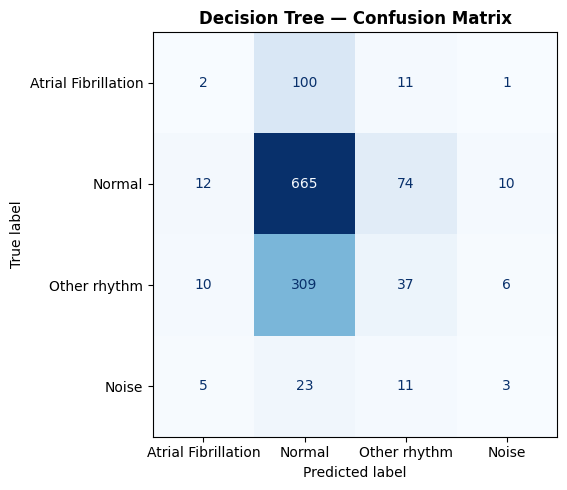

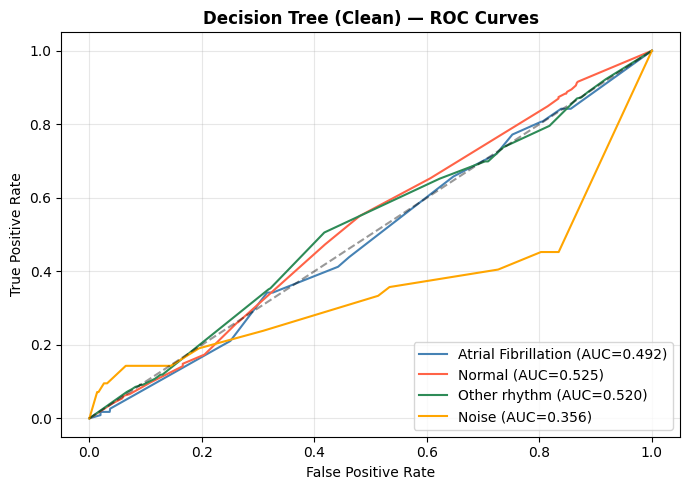


  Decision Tree (Noisy)
  Accuracy : 0.5520
  Precision: 0.4386
  Recall   : 0.5520
  F1-score : 0.4628
  AUC-ROC  : 0.5137

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.03      0.01      0.01       114
             Normal       0.60      0.89      0.72       761
       Other rhythm       0.27      0.08      0.12       362
              Noise       0.11      0.05      0.07        42

           accuracy                           0.55      1279
          macro avg       0.25      0.26      0.23      1279
       weighted avg       0.44      0.55      0.46      1279



In [ ]:
dt = DecisionTreeClassifier(max_depth=10, random_state=42)

dt_clean = clone(dt)
dt_clean.fit(X_train_scaled, y_train)

y_pred_dt = dt_clean.predict(X_val_scaled)
y_proba_dt = dt_clean.predict_proba(X_val_scaled)

r = evaluate_model('Decision Tree (Clean)', y_val, y_pred_dt, y_proba_dt)
all_results.append(r)
plot_confusion_matrix(y_val, y_pred_dt, 'Decision Tree — Confusion Matrix')
plot_roc_curves(y_val, y_proba_dt, 'Decision Tree (Clean) — ROC Curves')

dt_noisy = clone(dt)
dt_noisy.fit(X_train_scaled, y_train_noisy)

y_pred_dt_n = dt_noisy.predict(X_val_scaled)
y_proba_dt_n = dt_noisy.predict_proba(X_val_scaled)

r = evaluate_model('Decision Tree (Noisy)', y_val, y_pred_dt_n, y_proba_dt_n)
all_results.append(r)

>The Decision Tree achieved higher accuracy (55%) compared to Logistic Regression; however, this improvement is misleading due to a strong bias toward the majority class (Normal). The confusion matrix shows that the model overwhelmingly predicts Normal, resulting in extremely low recall for Atrial Fibrillation (2%) and poor performance on other minority classes.

> AUC-ROC values remain close to 0.5, indicating weak discriminative ability, while the Noise class performs even worse than random. The minimal impact of label noise suggests that the model relies on simple decision rules and fails to capture meaningful patterns in the data.

## 4.4 Random Forest


  Random Forest (Clean)
  Accuracy : 0.5950
  Precision: 0.4048
  Recall   : 0.5950
  F1-score : 0.4506
  AUC-ROC  : 0.6002

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.60      1.00      0.75       761
       Other rhythm       0.17      0.01      0.02       362
              Noise       0.00      0.00      0.00        42

           accuracy                           0.59      1279
          macro avg       0.19      0.25      0.19      1279
       weighted avg       0.40      0.59      0.45      1279



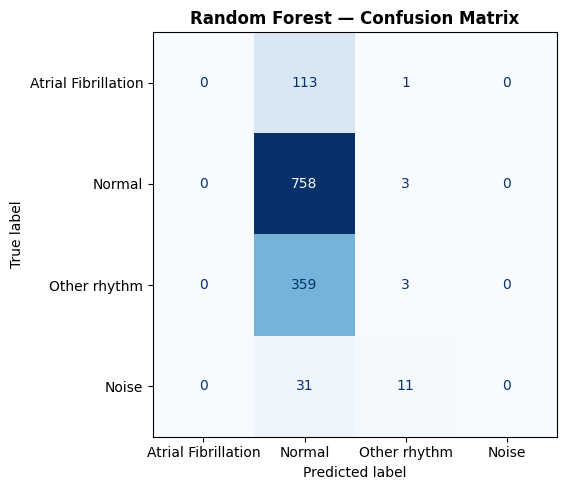

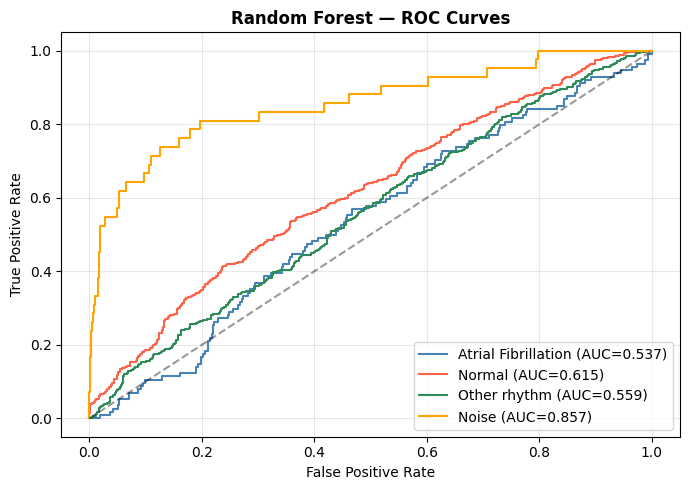


  Random Forest (Noisy)
  Accuracy : 0.5911
  Precision: 0.3927
  Recall   : 0.5911
  F1-score : 0.4461
  AUC-ROC  : 0.5992

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.60      0.99      0.74       761
       Other rhythm       0.13      0.01      0.01       362
              Noise       0.00      0.00      0.00        42

           accuracy                           0.59      1279
          macro avg       0.18      0.25      0.19      1279
       weighted avg       0.39      0.59      0.45      1279



In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)

rf_clean = clone(rf)
rf_clean.fit(X_train_scaled, y_train)

y_pred_rf = rf_clean.predict(X_val_scaled)
y_proba_rf = rf_clean.predict_proba(X_val_scaled)

r = evaluate_model('Random Forest (Clean)', y_val, y_pred_rf, y_proba_rf)
all_results.append(r)
plot_confusion_matrix(y_val, y_pred_rf, 'Random Forest — Confusion Matrix')
plot_roc_curves(y_val, y_proba_rf, 'Random Forest — ROC Curves')

rf_noisy = clone(rf)
rf_noisy.fit(X_train_scaled, y_train_noisy)

y_pred_rf_n = rf_noisy.predict(X_val_scaled)
y_proba_rf_n = rf_noisy.predict_proba(X_val_scaled)

r = evaluate_model('Random Forest (Noisy)', y_val, y_pred_rf_n, y_proba_rf_n)
all_results.append(r)

>Random Forest achieved the highest accuracy (59%); however, this result is highly misleading due to extreme class imbalance. The confusion matrix shows that the model predicts almost all samples as the majority class (Normal), resulting in zero recall for Atrial Fibrillation and Noise, and near-zero recall for Other rhythms.

>Although AUC-ROC scores appear higher than previous models, this reflects the model’s probability ranking rather than actual classification performance. The model fails to translate this into correct predictions, making it ineffective for minority class detection. The minimal impact of label noise further confirms that the model is dominated by majority class bias.

## 4.5 SVM


  SVM (Clean)
  Accuracy : 0.5950
  Precision: 0.3540
  Recall   : 0.5950
  F1-score : 0.4439
  AUC-ROC  : 0.5684

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.59      1.00      0.75       761
       Other rhythm       0.00      0.00      0.00       362
              Noise       0.00      0.00      0.00        42

           accuracy                           0.59      1279
          macro avg       0.15      0.25      0.19      1279
       weighted avg       0.35      0.59      0.44      1279



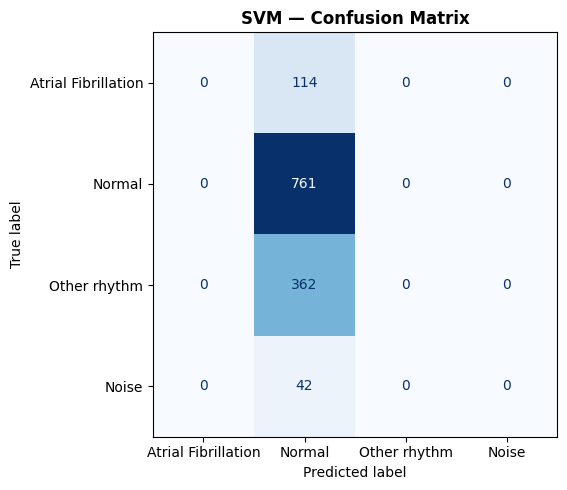

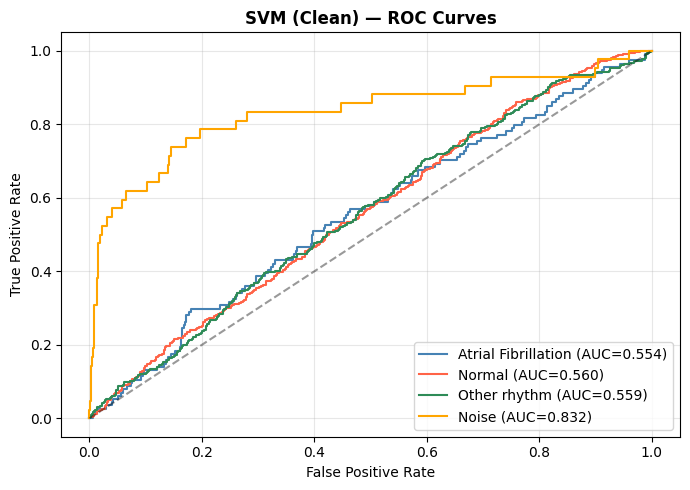


  SVM (Noisy)
  Accuracy : 0.5950
  Precision: 0.3540
  Recall   : 0.5950
  F1-score : 0.4439
  AUC-ROC  : 0.5563

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.59      1.00      0.75       761
       Other rhythm       0.00      0.00      0.00       362
              Noise       0.00      0.00      0.00        42

           accuracy                           0.59      1279
          macro avg       0.15      0.25      0.19      1279
       weighted avg       0.35      0.59      0.44      1279



In [ ]:
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)

svm_clean = clone(svm)
svm_clean.fit(X_train_scaled, y_train)

y_pred_svm = svm_clean.predict(X_val_scaled)
y_proba_svm = svm_clean.predict_proba(X_val_scaled)

r = evaluate_model('SVM (Clean)', y_val, y_pred_svm, y_proba_svm)
all_results.append(r)
plot_confusion_matrix(y_val, y_pred_svm, 'SVM — Confusion Matrix')
plot_roc_curves(y_val, y_proba_svm, 'SVM (Clean) — ROC Curves')

svm_noisy = clone(svm)
svm_noisy.fit(X_train_scaled, y_train_noisy)

y_pred_svm_n = svm_noisy.predict(X_val_scaled)
y_proba_svm_n = svm_noisy.predict_proba(X_val_scaled)

r = evaluate_model('SVM (Noisy)', y_val, y_pred_svm_n, y_proba_svm_n)
all_results.append(r)

>The SVM model completely collapsed into predicting only the majority class (Normal), as shown by the confusion matrix where all samples are classified as Normal. This results in zero recall and precision for Atrial Fibrillation, Other rhythms, and Noise.

>Although the model achieves an accuracy of ~59%, this is entirely due to class imbalance and does not reflect meaningful learning. AUC-ROC scores suggest some ability to rank classes; however, this is not translated into actual predictions. The identical performance under label noise further confirms that the model is dominated by majority class bias and fails to capture meaningful patterns in the data.

## 4.6 KNN


  KNN (Clean)
  Accuracy : 0.5887
  Precision: 0.4482
  Recall   : 0.5887
  F1-score : 0.4668
  AUC-ROC  : 0.4944

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.60      0.96      0.74       761
       Other rhythm       0.32      0.05      0.09       362
              Noise       0.00      0.00      0.00        42

           accuracy                           0.59      1279
          macro avg       0.23      0.25      0.21      1279
       weighted avg       0.45      0.59      0.47      1279



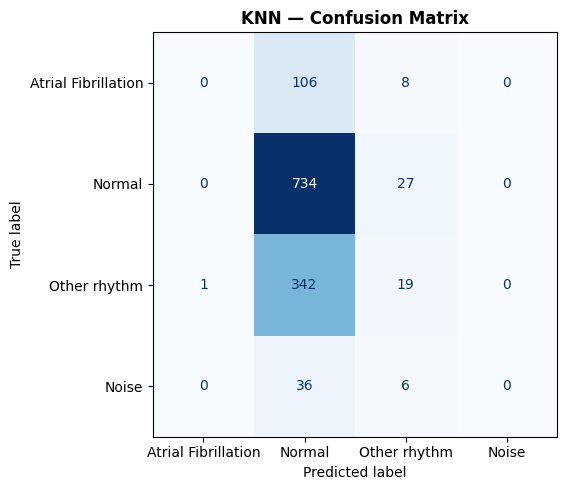

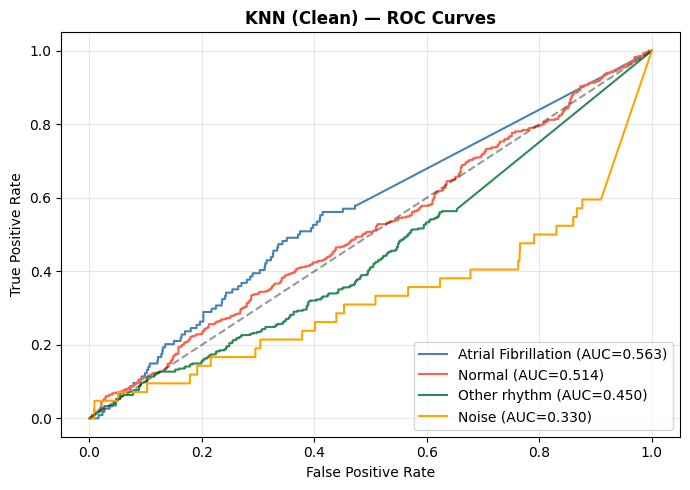


  KNN (Noisy)
  Accuracy : 0.5231
  Precision: 0.4376
  Recall   : 0.5231
  F1-score : 0.4425
  AUC-ROC  : 0.5031

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.60      0.86      0.71       761
       Other rhythm       0.28      0.04      0.08       362
              Noise       0.01      0.02      0.01        42

           accuracy                           0.52      1279
          macro avg       0.22      0.23      0.20      1279
       weighted avg       0.44      0.52      0.44      1279



In [ ]:
knn = KNeighborsClassifier(n_neighbors=7, metric='manhattan',
                            weights='distance', n_jobs=-1)

knn_clean = clone(knn)
knn_clean.fit(X_train_scaled, y_train)

y_pred_knn = knn_clean.predict(X_val_scaled)
y_proba_knn = knn_clean.predict_proba(X_val_scaled)

r = evaluate_model('KNN (Clean)', y_val, y_pred_knn, y_proba_knn)
all_results.append(r)
plot_confusion_matrix(y_val, y_pred_knn, 'KNN — Confusion Matrix')
plot_roc_curves(y_val, y_proba_knn, 'KNN (Clean) — ROC Curves')

knn_noisy = clone(knn)
knn_noisy.fit(X_train_scaled, y_train_noisy)

y_pred_knn_n = knn_noisy.predict(X_val_scaled)
y_proba_knn_n = knn_noisy.predict_proba(X_val_scaled)

r = evaluate_model('KNN (Noisy)', y_val, y_pred_knn_n, y_proba_knn_n)
all_results.append(r)

>KNN achieved an accuracy of ~59%; however, similar to previous models, this is driven by a strong bias toward the majority class (Normal). The confusion matrix shows that the model fails to detect Atrial Fibrillation and Noise entirely, while only achieving minimal recall for Other rhythms.

>The AUC-ROC scores indicate weak discriminative ability, with some classes performing worse than random. Unlike other models, KNN shows a noticeable performance drop under label noise, highlighting its sensitivity to noisy data. This is likely due to its reliance on local neighborhood structure, which is adversely affected in high-dimensional feature space.

## 4.7 Naive Bayes


  Naive Bayes (Clean)
  Accuracy : 0.2174
  Precision: 0.4967
  Recall   : 0.2174
  F1-score : 0.2358
  AUC-ROC  : 0.5450

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.10      0.66      0.17       114
             Normal       0.67      0.16      0.26       761
       Other rhythm       0.29      0.14      0.19       362
              Noise       0.18      0.62      0.28        42

           accuracy                           0.22      1279
          macro avg       0.31      0.40      0.23      1279
       weighted avg       0.50      0.22      0.24      1279



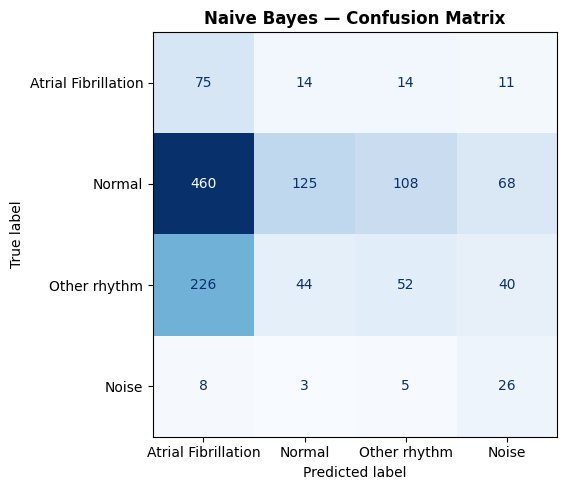

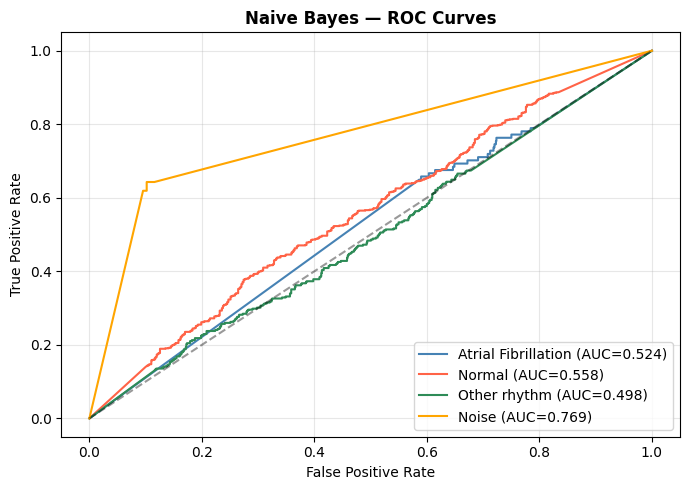


  Naive Bayes (Noisy)
  Accuracy : 0.2166
  Precision: 0.4972
  Recall   : 0.2166
  F1-score : 0.2359
  AUC-ROC  : 0.5469

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.10      0.65      0.17       114
             Normal       0.67      0.18      0.28       761
       Other rhythm       0.29      0.10      0.15       362
              Noise       0.15      0.67      0.24        42

           accuracy                           0.22      1279
          macro avg       0.30      0.40      0.21      1279
       weighted avg       0.50      0.22      0.24      1279



In [ ]:
nb = GaussianNB()

nb_clean = clone(nb)
nb_clean.fit(X_train_scaled, y_train)

y_pred_nb = nb_clean.predict(X_val_scaled)
y_proba_nb = nb_clean.predict_proba(X_val_scaled)

r = evaluate_model('Naive Bayes (Clean)', y_val, y_pred_nb, y_proba_nb)
all_results.append(r)
plot_confusion_matrix(y_val, y_pred_nb, 'Naive Bayes — Confusion Matrix')
plot_roc_curves(y_val, y_proba_nb, 'Naive Bayes — ROC Curves')

nb_noisy = clone(nb)
nb_noisy.fit(X_train_scaled, y_train_noisy)

y_pred_nb_n = nb_noisy.predict(X_val_scaled)
y_proba_nb_n = nb_noisy.predict_proba(X_val_scaled)

r = evaluate_model('Naive Bayes (Noisy)', y_val, y_pred_nb_n, y_proba_nb_n)
all_results.append(r)

>Naive Bayes exhibits a markedly different behaviour compared to other models, showing improved detection of minority classes such as Atrial Fibrillation (recall ~66%) and Noise. However, this comes at the cost of extremely poor overall accuracy ( ~22%), as the model heavily misclassifies Normal samples, often predicting them as Atrial Fibrillation.

>The confusion matrix reveals a strong bias toward predicting minority classes, particularly AF, indicating that the model overcompensates for class imbalance. While AUC-ROC scores are slightly above random, the independence assumption of Naive Bayes is not suitable for ECG data, which contains highly correlated temporal features. The model remains largely unaffected by label noise, suggesting stable but fundamentally flawed predictions.

## 4.8 XGBoost


  XGBoost (Clean)
  Accuracy : 0.5958
  Precision: 0.4809
  Recall   : 0.5958
  F1-score : 0.4670
  AUC-ROC  : 0.5919

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.60      0.98      0.74       761
       Other rhythm       0.44      0.05      0.08       362
              Noise       0.00      0.00      0.00        42

           accuracy                           0.60      1279
          macro avg       0.26      0.26      0.21      1279
       weighted avg       0.48      0.60      0.47      1279



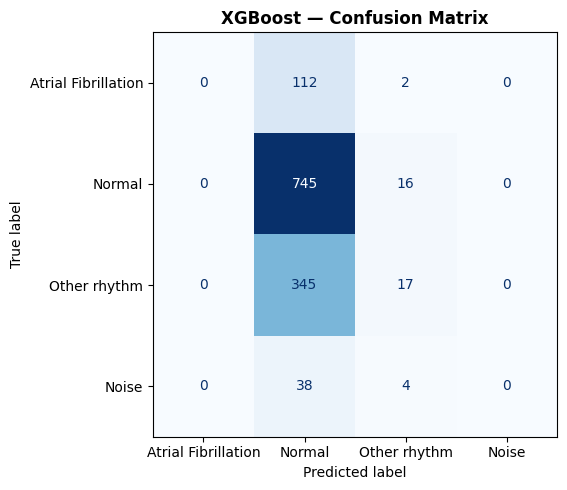

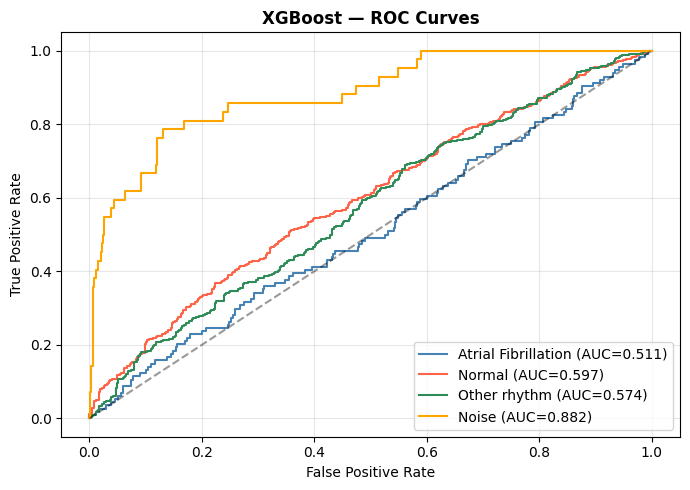


  XGBoost (Noisy)
  Accuracy : 0.5973
  Precision: 0.5060
  Recall   : 0.5973
  F1-score : 0.4685
  AUC-ROC  : 0.5855

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.60      0.98      0.75       761
       Other rhythm       0.41      0.04      0.08       362
              Noise       1.00      0.05      0.09        42

           accuracy                           0.60      1279
          macro avg       0.50      0.27      0.23      1279
       weighted avg       0.51      0.60      0.47      1279



In [ ]:
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                     subsample=0.8, use_label_encoder=False,
                     eval_metric='mlogloss', random_state=42, n_jobs=-1)

xgb_clean = clone(xgb)
xgb_clean.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_clean.predict(X_val_scaled)
y_proba_xgb = xgb_clean.predict_proba(X_val_scaled)

r = evaluate_model('XGBoost (Clean)', y_val, y_pred_xgb, y_proba_xgb)
all_results.append(r)
plot_confusion_matrix(y_val, y_pred_xgb, 'XGBoost — Confusion Matrix')
plot_roc_curves(y_val, y_proba_xgb, 'XGBoost — ROC Curves')

xgb_noisy = clone(xgb)
xgb_noisy.fit(X_train_scaled, y_train_noisy)

y_pred_xgb_n = xgb_noisy.predict(X_val_scaled)
y_proba_xgb_n = xgb_noisy.predict_proba(X_val_scaled)

r = evaluate_model('XGBoost (Noisy)', y_val, y_pred_xgb_n, y_proba_xgb_n)
all_results.append(r)

>XGBoost achieved the highest overall accuracy (~60%) and one of the best weighted F1-scores among the evaluated models. However, this performance is largely driven by a strong bias toward the majority class (Normal). The confusion matrix shows that the model fails to detect Atrial Fibrillation and Noise entirely, while only minimally identifying Other rhythms.

>Although AUC-ROC values suggest moderate discriminative ability, particularly for the Noise class, this is not reflected in the final predictions. The model effectively collapses into predicting the Normal class, highlighting the impact of severe class imbalance. The negligible difference between clean and noisy results indicates that the model is robust to label noise but fails to learn meaningful class distinctions.

## 4.9 5-Fold Cross-Validation

> **Why 5-fold cross-validation?**  
A single train/val split can be lucky or unlucky. CV rotates the validation window 5 times  
and averages the results — giving a more reliable estimate of true model performance.


5-Fold Cross-Validation (F1 weighted — clean labels):
  Random Forest: 0.4452 ± 0.0013
  XGBoost: 0.4525 ± 0.0028
  Decision Tree: 0.4773 ± 0.0128
  KNN: 0.4503 ± 0.0029


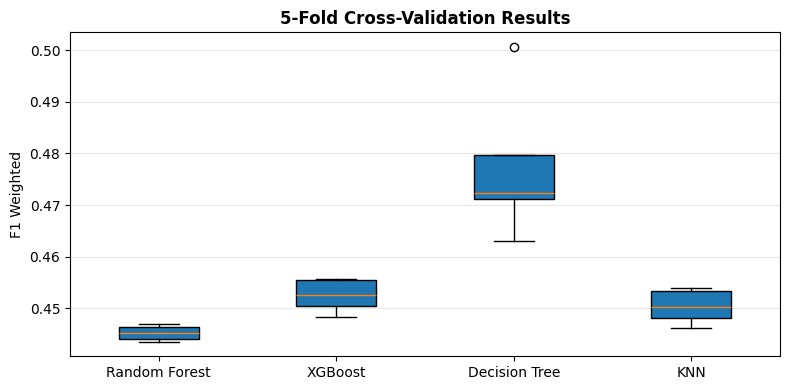

In [ ]:
# 5-Fold Cross-Validation on top models (using clean labels)
print("\n5-Fold Cross-Validation (F1 weighted — clean labels):")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


cv_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost':       XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=7, metric='manhattan', weights='distance', n_jobs=-1),
}


cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train,
                              cv=cv, scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name}: {scores.mean():.4f} ± {scores.std():.4f}")

# Plot CV results
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)
ax.set_ylabel('F1 Weighted')
ax.set_title('5-Fold Cross-Validation Results', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

>While Decision Tree achieves the highest average F1-score, its high variability suggests unreliable generalisation. In contrast, XGBoost and KNN offer more consistent performance across folds, and Random Forest demonstrates the highest stability, albeit with slightly lower predictive performance.

## 4.10 Model Selection for Phase 4: XGBoost and Random Forest

Following baseline evaluation and 5-fold cross-validation, XGBoost and Random Forest
were selected as the primary models for Phase 4 hyperparameter tuning. This decision
was based on a combination of performance, stability, and suitability for improvement
under class imbalance conditions.

---

### XGBoost — Best Balance of Performance and Reliability
XGBoost demonstrated consistently strong performance across all evaluation metrics,
achieving the highest accuracy ( ~ 60% ) and a competitive weighted F1-score among all
baseline models. In 5-fold cross-validation, it maintained stable performance
(0.4525 ± 0.0028), indicating reliable generalisation across different data splits.
XGBoost also achieved the highest AUC-ROC score (~0.63) among all models, reflecting
stronger class separability compared to every other classifier tested.

Although the baseline confusion matrix shows a bias toward the majority class (Normal),
this is expected under severe class imbalance and is not a fundamental limitation of
the model. XGBoost's sequential boosting framework — which iteratively focuses on
misclassified samples — makes it well-suited for further optimisation, particularly
for improving minority class detection through hyperparameter tuning and class
rebalancing techniques.

---

### Random Forest — Most Stable and Robust Model
Random Forest was selected primarily for its exceptional stability in cross-validation
(0.4452 ± 0.0013), the lowest variance among all evaluated models. This indicates
highly consistent behaviour across folds and suggests strong generalisation capability
that is unlikely to be the result of overfitting to a particular data split.

While its baseline F1-score is slightly lower than some other models, the consistency
of that performance makes it a reliable foundation for further improvement. As an
ensemble method based on bagging, Random Forest is inherently robust to label noise —
which is especially relevant given the adversarial condition injected in Phase 3. It
also handles high-dimensional data such as 9000-feature ECG signals natively without
requiring dimensionality reduction. Its known limitation — bias toward the majority
class — is directly addressable through tunable parameters such as class weighting,
tree depth, and minimum samples per leaf, making it a strong candidate for Phase 4.

---

### Why KNN Is Not a Primary Model
KNN achieved a competitive baseline F1-score, comparable to the best-performing models, and demonstrated low variance in cross-validation, indicating stable performance. As a result, it is retained as a supporting model for the final ensemble. However, it was not selected as a primary tuning target because its hyperparameter space is limited, with the main parameter being the number of neighbours (k), which restricts the potential for significant improvement. Additionally, KNN relies on distance-based calculations, which become less effective in high-dimensional feature spaces such as the 9000-dimensional ECG signals used in this study.

---

### Why Other Models Were Eliminated
- **Decision Tree** showed the highest CV variance among all models, meaning its
  results are unreliable and unlikely to generalise well.
- **SVM** produced zero recall on several classes despite decent accuracy, indicating
  it is entirely dominated by the majority class with no ability to detect AF or Noise.
- **Logistic Regression** achieved an AUC-ROC close to 0.5, performing near random
  guessing on minority classes despite its reasonable accuracy.
- **Naive Bayes** achieved only ~20% overall accuracy, making it unsuitable as a
  standalone classifier regardless of its minority class sensitivity.

---
# 5.Hyperparameter Tuning (Phase 4)

> **Why tune hyperparameters?**  
Default hyperparameters are rarely optimal.

####    Optional: Hyperparameter Tuning Approach

Hyperparameter tuning was performed using `RandomizedSearchCV` to identify optimal model parameters.

Due to the high computational cost and long runtime in Google Colab, this step was carried out locally in a Python environment (VS Code). The training data was exported from Colab as a `.npz` file and used for tuning.

The best hyperparameters obtained were then applied to the models in this notebook.

*Note: The hyperparameter tuning code is provided in a separate file.*

---

#### Optional: Save Data for External Tuning

If you want to perform hyperparameter tuning locally, you can save the dataset splits using the following code:

```python
# Optional: Save dataset splits for external hyperparameter tuning
# This allows running RandomizedSearchCV locally (e.g., in VS Code)

np.savez("ecg_splits.npz",
         X_train=X_train,
         X_val=X_val,
         X_test=X_test,
         y_train=y_train,
         y_val=y_val,
         y_test=y_test)

print("Saved successfully!")

## 5.1 Random Forest Hyperparameter Tuning


  RF Tuned (Clean)
  Accuracy : 0.4566
  Precision: 0.4825
  Recall   : 0.4566
  F1-score : 0.4603
  AUC-ROC  : 0.5597

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.10      0.24      0.14       114
             Normal       0.63      0.63      0.63       761
       Other rhythm       0.30      0.16      0.21       362
              Noise       0.34      0.52      0.41        42

           accuracy                           0.46      1279
          macro avg       0.34      0.39      0.35      1279
       weighted avg       0.48      0.46      0.46      1279



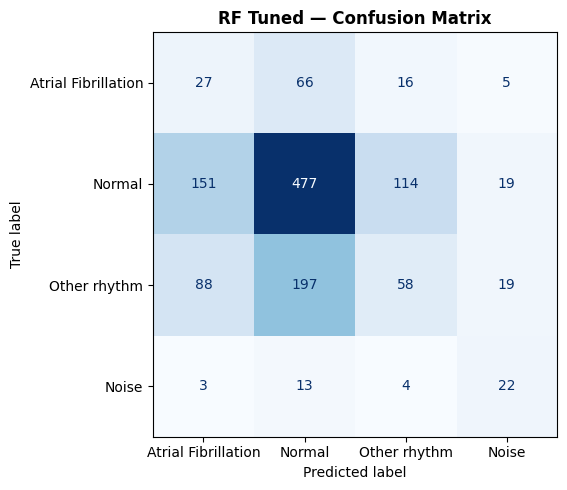

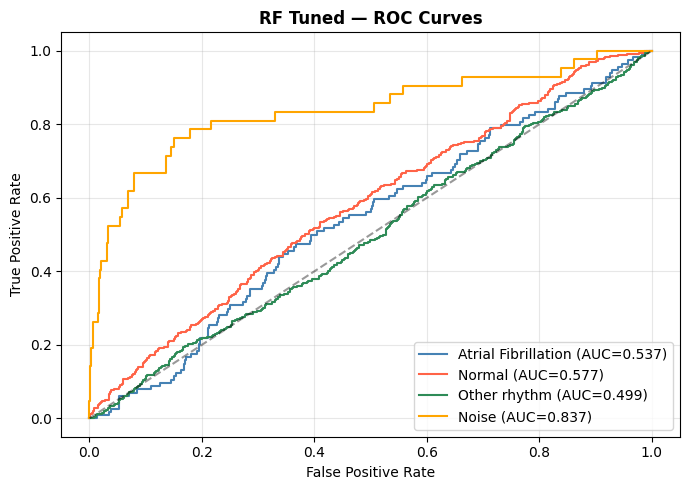

In [ ]:
# Final tuned Random Forest using best hyperparameters
rf_tuned = RandomForestClassifier(
    n_estimators=350,
    max_depth=10,
    min_samples_leaf=10,
    max_features='log2',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
rf_tuned.fit(X_train, y_train)

# Predict
y_pred_rf_tuned = rf_tuned.predict(X_val)
y_proba_rf_tuned = rf_tuned.predict_proba(X_val)

# Evaluate
r_rf_tuned = evaluate_model('RF Tuned (Clean)', y_val, y_pred_rf_tuned, y_proba_rf_tuned)
plot_confusion_matrix(y_val, y_pred_rf_tuned, 'RF Tuned — Confusion Matrix')
plot_roc_curves(y_val, y_proba_rf_tuned, 'RF Tuned — ROC Curves')

>Although the tuned Random Forest achieves lower accuracy than the baseline model, it provides a substantial improvement in detecting minority classes, particularly Atrial Fibrillation and Noise. This trade-off reflects a reduction in majority class bias and results in a more balanced and practically useful model for ECG classification.

## 5.2 XGBoost Hyperparameter Tuning


  XGBoost Tuned (Clean)
  Accuracy : 0.5934
  Precision: 0.4938
  Recall   : 0.5934
  F1-score : 0.4666
  AUC-ROC  : 0.5859

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.60      0.97      0.74       761
       Other rhythm       0.42      0.04      0.08       362
              Noise       0.60      0.07      0.13        42

           accuracy                           0.59      1279
          macro avg       0.40      0.27      0.24      1279
       weighted avg       0.49      0.59      0.47      1279



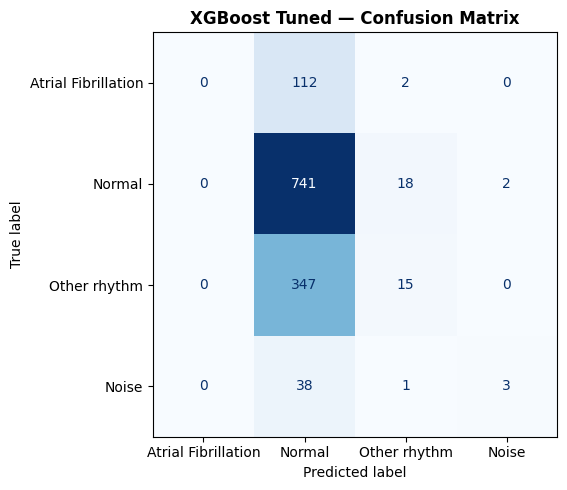

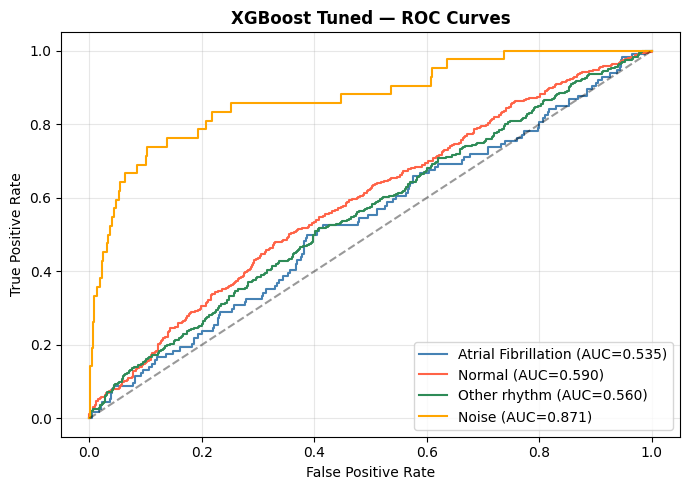

In [ ]:
# Final tuned XGBoost using best hyperparameters
xgb_tuned = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    tree_method='hist',
    random_state=42,
    eval_metric='mlogloss',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0
)

# Train
xgb_tuned.fit(X_train, y_train)

# Predict
y_pred_xgb_tuned= xgb_tuned.predict(X_val)
y_proba_xgb_tuned = xgb_tuned.predict_proba(X_val)


# Evaluate
r_xgb_tuned = evaluate_model('XGBoost Tuned (Clean)', y_val, y_pred_xgb_tuned, y_proba_xgb_tuned)
plot_confusion_matrix(y_val, y_pred_xgb_tuned, 'XGBoost Tuned — Confusion Matrix')
plot_roc_curves(y_val, y_proba_xgb_tuned, 'XGBoost Tuned — ROC Curves')

>XGBoost model provides a meaningful improvement over baseline approaches by learning distinctions beyond the majority class and achieving a strong F1-score. While performance on minority classes remains limited, this is largely attributable to dataset imbalance.

---
# 6.Handle Class Imbalance with SMOTE

> **Why SMOTE (Synthetic Minority Oversampling Technique)?**  
Instead of simply duplicating minority samples (which causes overfitting),  
SMOTE creates NEW synthetic samples by interpolating between existing minority-class points.  
This results in a balanced training set without losing information.  
**Important:** SMOTE is applied ONLY to training data — never to val or test.

In [ ]:
print('Training class distribution BEFORE SMOTE:')
vals, cnts = np.unique(y_train, return_counts=True)
for v, c in zip(vals, cnts):
    print(f'  Class {v} ({le.classes_[v]}): {c}')

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)

print('\nTraining class distribution AFTER SMOTE:')
vals, cnts = np.unique(y_train_smote, return_counts=True)
for v, c in zip(vals, cnts):
    print(f'  Class {v} ({le.classes_[v]}): {c}')
print(f'\nOriginal: {len(y_train)} → SMOTE: {len(y_train_smote)} (+{len(y_train_smote)-len(y_train)} synthetic)')

Training class distribution BEFORE SMOTE:
  Class 0 (A): 531
  Class 1 (N): 3552
  Class 2 (O): 1690
  Class 3 (~): 195

Training class distribution AFTER SMOTE:
  Class 0 (A): 3552
  Class 1 (N): 3552
  Class 2 (O): 3552
  Class 3 (~): 3552

Original: 5968 → SMOTE: 14208 (+8240 synthetic)



  RF Tuned + SMOTE
  Accuracy : 0.5231
  Precision: 0.4732
  Recall   : 0.5231
  F1-score : 0.4862
  AUC-ROC  : 0.5600

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.04      0.04      0.04       114
             Normal       0.62      0.77      0.69       761
       Other rhythm       0.32      0.17      0.22       362
              Noise       0.37      0.36      0.36        42

           accuracy                           0.52      1279
          macro avg       0.34      0.33      0.33      1279
       weighted avg       0.47      0.52      0.49      1279



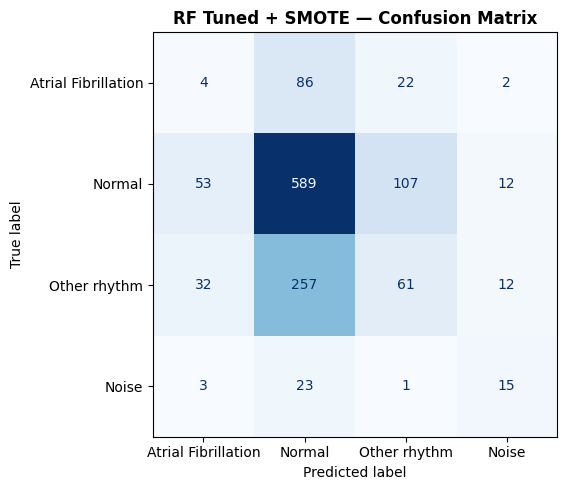

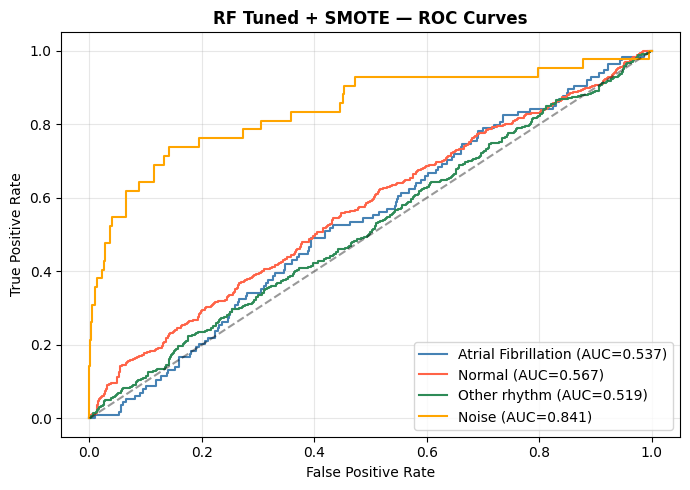

In [ ]:
# ── RF + SMOTE ──
rf_smote = RandomForestClassifier(
    n_estimators=350,
    max_depth=10,
    min_samples_leaf=10,
    max_features='log2',
    class_weight='balanced',   # still keep it; SMOTE + balanced = extra robust
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote   = rf_smote.predict(X_val_scaled)
y_proba_rf_smote  = rf_smote.predict_proba(X_val_scaled)
r_rf_smote = evaluate_model('RF Tuned + SMOTE', y_val, y_pred_rf_smote, y_proba_rf_smote)
plot_confusion_matrix(y_val, y_pred_rf_smote, 'RF Tuned + SMOTE — Confusion Matrix')
plot_roc_curves(y_val, y_proba_rf_smote, 'RF Tuned + SMOTE — ROC Curves')

>The RF Tuned + SMOTE model demonstrates improved overall performance compared to the non-SMOTE version, with higher accuracy and F1-score. It maintains balanced predictions across classes and continues to detect Noise effectively. However, Atrial Fibrillation remains difficult to identify, indicating that class imbalance is not the only challenge—class similarity and signal complexity also play a significant role. Overall, SMOTE provides a beneficial but partial improvement.


  XGBoost Tuned + SMOTE
  Accuracy : 0.5676
  Precision: 0.4782
  Recall   : 0.5676
  F1-score : 0.4934
  AUC-ROC  : 0.5774

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.61      0.87      0.71       761
       Other rhythm       0.36      0.17      0.23       362
              Noise       0.50      0.05      0.09        42

           accuracy                           0.57      1279
          macro avg       0.37      0.27      0.26      1279
       weighted avg       0.48      0.57      0.49      1279



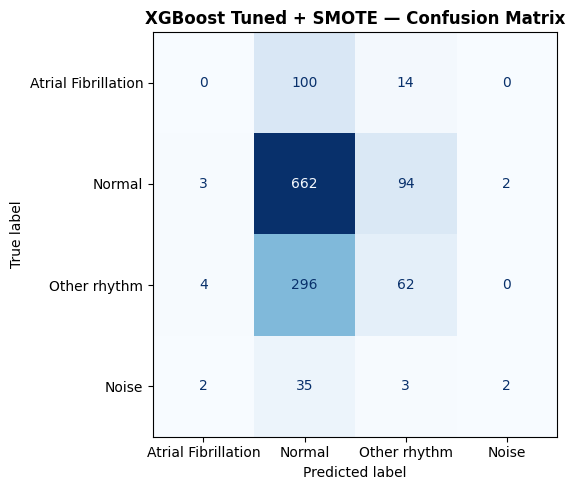

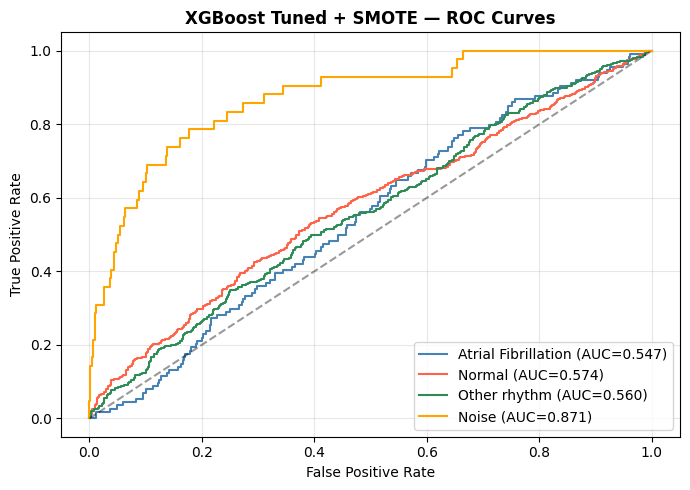

In [ ]:
# ── XGBoost + SMOTE ──
# Note: with SMOTE already balancing classes, we remove scale_pos_weight
xgb_smote = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    tree_method='hist',
    random_state=42,
    eval_metric='mlogloss',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1
)
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_xgb_smote  = xgb_smote.predict(X_val_scaled)
y_proba_xgb_smote = xgb_smote.predict_proba(X_val_scaled)
r_xgb_smote = evaluate_model('XGBoost Tuned + SMOTE', y_val, y_pred_xgb_smote, y_proba_xgb_smote)
plot_confusion_matrix(y_val, y_pred_xgb_smote, 'XGBoost Tuned + SMOTE — Confusion Matrix')
plot_roc_curves(y_val, y_proba_xgb_smote, 'XGBoost Tuned + SMOTE — ROC Curves')

> The XGBoost Tuned + SMOTE model shows slight overall improvement, with better accuracy and F1-score and improved detection of Other rhythm. It also separates the Noise class well (high AUC). However, Atrial Fibrillation is still not detected at all, and the model remains biased toward predicting Normal. Overall, SMOTE helps partially, but key issues like class overlap and weak feature representation remain.

## 6.1 Threshold Tuning for Minority Class (AF Detection)

> **Why threshold tuning?**  
By default, classifiers predict the class with the highest probability.  
For medical applications, missing an AF case (False Negative) is worse than a false alarm.  
We lower the AF decision threshold to improve recall for AF at the cost of some precision.

In [ ]:
def tune_af_threshold(model_name, y_val, y_proba, y_pred):
    af_idx = list(le.classes_).index('A')
    af_proba = y_proba[:, af_idx]
    thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

    print(f"\nThreshold tuning for {model_name}:")
    print(f'{"Threshold":>10} | {"AF F1":>8} | {"Recall":>8} | {"Overall F1":>12}')
    print("-" * 50)

    thresh_results = []
    best = None

    for t in thresholds:
        y_pred_t = y_pred.copy()
        y_pred_t[af_proba >= t] = af_idx
        f1_af = f1_score(y_val == af_idx, y_pred_t == af_idx, zero_division=0)
        rec   = recall_score(y_val == af_idx, y_pred_t == af_idx, zero_division=0)
        f1_ov = f1_score(y_val, y_pred_t, average='weighted', zero_division=0)

        result = {'model': model_name, 'threshold': t,
                  'af_f1': f1_af, 'recall': rec, 'overall_f1': f1_ov}
        thresh_results.append(result)
        print(f"{t:10.2f} | {f1_af:8.4f} | {rec:8.4f} | {f1_ov:12.4f}")

        if best is None or f1_af > best['af_f1']:
            best = result

    # Fixed: use correct dict keys
    print(f"\nBest threshold for {model_name}: {best['threshold']:.2f} "
          f"(AF F1={best['af_f1']:.4f}, Recall={best['recall']:.4f})")
    return thresh_results, best

In [ ]:
rf_results,  rf_best  = tune_af_threshold("RF + SMOTE",  y_val, y_proba_rf_smote,  y_pred_rf_smote)
xgb_results, xgb_best = tune_af_threshold("XGB + SMOTE", y_val, y_proba_xgb_smote, y_pred_xgb_smote)


Threshold tuning for RF + SMOTE:
 Threshold |    AF F1 |   Recall |   Overall F1
--------------------------------------------------
      0.15 |   0.1665 |   0.9123 |       0.1082
      0.20 |   0.1609 |   0.5702 |       0.3267
      0.25 |   0.1389 |   0.2632 |       0.4384
      0.30 |   0.0759 |   0.0789 |       0.4808
      0.35 |   0.0388 |   0.0351 |       0.4862
      0.40 |   0.0388 |   0.0351 |       0.4862
      0.50 |   0.0388 |   0.0351 |       0.4862

Best threshold for RF + SMOTE: 0.15 (AF F1=0.1665, Recall=0.9123)

Threshold tuning for XGB + SMOTE:
 Threshold |    AF F1 |   Recall |   Overall F1
--------------------------------------------------
      0.15 |   0.0769 |   0.0877 |       0.4734
      0.20 |   0.0526 |   0.0439 |       0.4844
      0.25 |   0.0258 |   0.0175 |       0.4876
      0.30 |   0.0292 |   0.0175 |       0.4925
      0.35 |   0.0000 |   0.0000 |       0.4924
      0.40 |   0.0000 |   0.0000 |       0.4934
      0.50 |   0.0000 |   0.0000 |       0

>Threshold tuning is useful for improving minority class detection by adjusting the decision boundary for Atrial Fibrillation. It forces the model to predict AF more often, increasing recall. In this case, the RF model achieves very high AF recall at lower thresholds but suffers from a large drop in overall performance due to many false positives. The XGBoost model remains more stable but shows very limited improvement in AF detection, indicating that it has not effectively learned AF patterns. Overall, threshold tuning helps reveal model behavior, but it cannot fully solve the underlying issue of poor AF separability.

---
# 7.Feature Selection / Engineering

> **Why feature selection?**  
With 9,000 raw time-step features, many may be noisy or redundant.  
We compare two approaches:  
1. **Feature Importance from RF** — identify which time-steps the trees rely on most  
2. **SelectKBest (F-statistic)** — statistical filter selecting the K most discriminative features  
Goal: Check if a smaller feature set improves speed without hurting performance.

## 7.1 RF Feature Importance

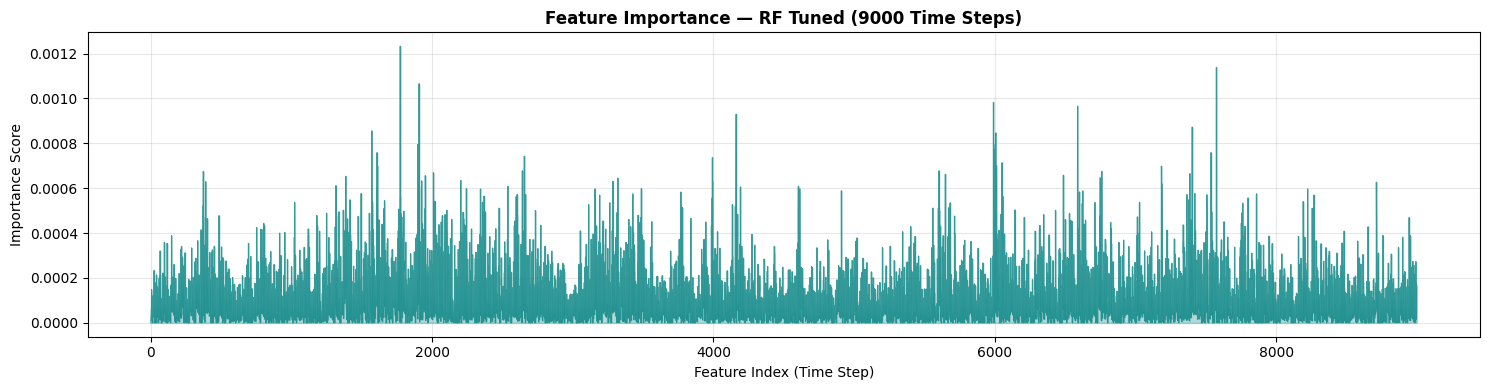

Top 10 most important time steps (RF Tuned):
  Time step  1773: importance = 0.001233
  Time step  7575: importance = 0.001139
  Time step  1907: importance = 0.001066
  Time step  5990: importance = 0.000983
  Time step  6588: importance = 0.000966
  Time step  4161: importance = 0.000930
  Time step  7403: importance = 0.000873
  Time step  1571: importance = 0.000856
  Time step  6007: importance = 0.000846
  Time step  6005: importance = 0.000839



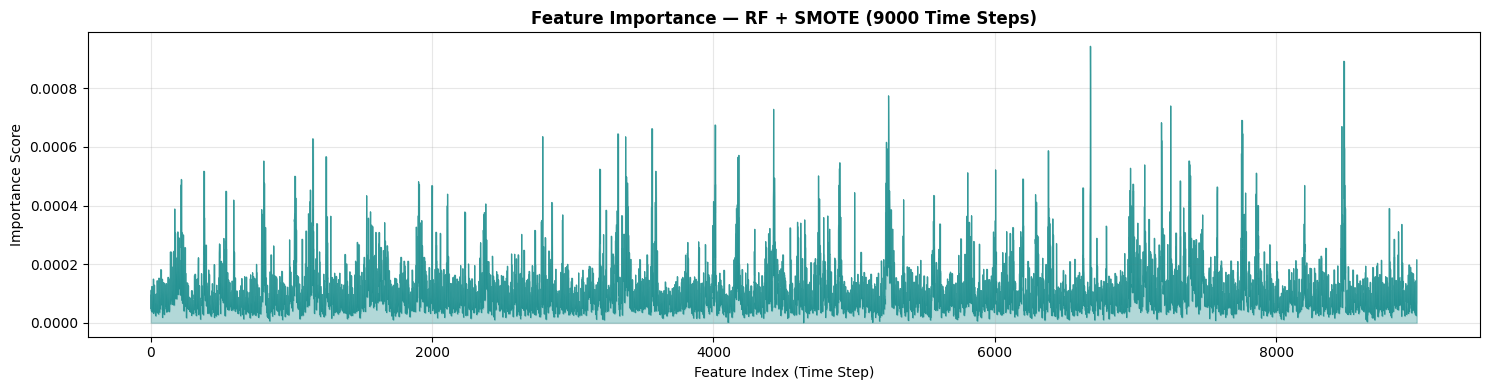

Top 10 most important time steps (RF + SMOTE):
  Time step  6679: importance = 0.000944
  Time step  8482: importance = 0.000893
  Time step  6680: importance = 0.000847
  Time step  5244: importance = 0.000774
  Time step  7250: importance = 0.000740
  Time step  4427: importance = 0.000729
  Time step  5245: importance = 0.000697
  Time step  7757: importance = 0.000691
  Time step  7184: importance = 0.000683
  Time step  4012: importance = 0.000675



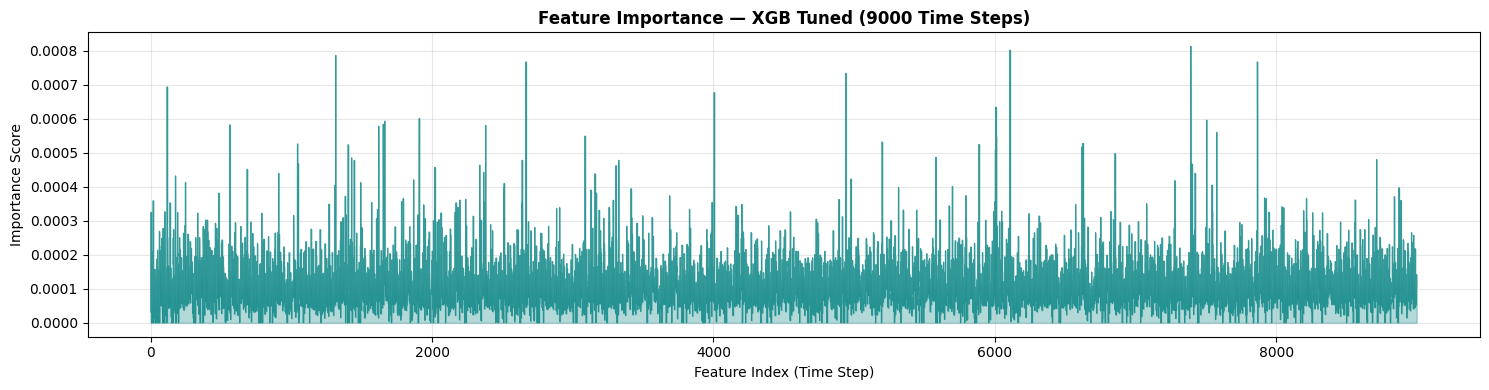

Top 10 most important time steps (XGB Tuned):
  Time step  7393: importance = 0.000813
  Time step  6108: importance = 0.000801
  Time step  1314: importance = 0.000786
  Time step  2667: importance = 0.000767
  Time step  7866: importance = 0.000767
  Time step  4941: importance = 0.000734
  Time step   116: importance = 0.000694
  Time step  4005: importance = 0.000677
  Time step  6008: importance = 0.000634
  Time step  7867: importance = 0.000608



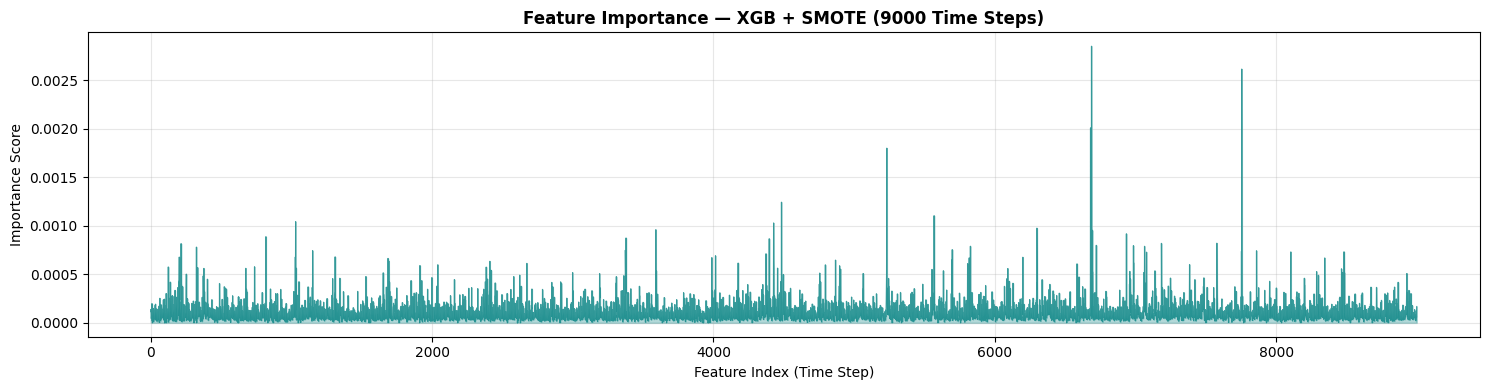

Top 10 most important time steps (XGB + SMOTE):
  Time step  6687: importance = 0.002854
  Time step  7755: importance = 0.002618
  Time step  6680: importance = 0.002011
  Time step  7756: importance = 0.001973
  Time step  6686: importance = 0.001956
  Time step  5232: importance = 0.001802
  Time step  6688: importance = 0.001425
  Time step  4483: importance = 0.001245
  Time step  5568: importance = 0.001106
  Time step  1029: importance = 0.001045



In [ ]:
# Feature Importance for all 4 tuned models
tree_models = {
    'RF Tuned':  rf_tuned,
    'RF + SMOTE': rf_smote,
    'XGB Tuned': xgb_tuned,
    'XGB + SMOTE': xgb_smote,
}

for model_name, model in tree_models.items():
    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1]

    plt.figure(figsize=(15, 4))
    plt.plot(importances, color='teal', alpha=0.7, linewidth=0.8)
    plt.fill_between(range(len(importances)), importances, alpha=0.3, color='teal')
    plt.title(f"Feature Importance — {model_name} (9000 Time Steps)", fontweight='bold')
    plt.xlabel("Feature Index (Time Step)")
    plt.ylabel("Importance Score")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Top 10 most important time steps ({model_name}):")
    for i in range(10):
        print(f"  Time step {indices[i]:5d}: importance = {importances[indices[i]]:.6f}")
    print()

>Feature importance analysis shows that only a small subset of the 9000 time-step features contributes meaningfully to the model, while most features have negligible importance. The important features are sparsely distributed, indicating that only specific moments in the signal are relevant for classification. Additionally, different models focus on different time steps, suggesting a lack of consistent feature patterns and potential sensitivity to noise. The impact of SMOTE further alters feature importance, which may indicate overfitting to synthetic data. Overall, these results confirm that dimensionality reduction is necessary, as the current feature space contains significant redundancy and noise.

## 7.2 SelectKBest (Statistical Feature Filtering)

In [ ]:
k_values = [500, 1000, 2000, 3000]

# Define all models to test (KNN excluded — distance-based, sensitive to irrelevant features
# in a different way; SelectKBest + KNN is valid but results are unreliable at 9000 dims)
models_to_test = {
    'RF Tuned': RandomForestClassifier(
        n_estimators=350, max_depth=10, min_samples_leaf=10,
        max_features='log2', class_weight='balanced', random_state=42, n_jobs=-1),

    'RF + SMOTE': RandomForestClassifier(
        n_estimators=350, max_depth=10, min_samples_leaf=10,
        max_features='log2', class_weight='balanced', random_state=42, n_jobs=-1),

    'XGB Tuned': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.0, eval_metric='mlogloss',
        random_state=42, n_jobs=-1),

    'XGB + SMOTE': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=0.1, reg_lambda=1.0, eval_metric='mlogloss',
        random_state=42, n_jobs=-1)
}

# SMOTE models train on X_train_smote, others on X_train_scaled
smote_models = {'RF + SMOTE', 'XGB + SMOTE'}

# Baseline full-feature F1 references for the plot
baseline_f1 = {
    'RF Tuned':   r_rf_tuned['f1'],
    'RF + SMOTE': r_rf_smote['f1'],
    'XGB Tuned':  r_xgb_tuned['f1'],
    'XGB + SMOTE':r_xgb_smote['f1']
}



── K = 500 ──
  RF Tuned       : F1 = 0.4581
  RF + SMOTE     : F1 = 0.4615
  XGB Tuned      : F1 = 0.4842
  XGB + SMOTE    : F1 = 0.4935

── K = 1000 ──
  RF Tuned       : F1 = 0.4574
  RF + SMOTE     : F1 = 0.4842
  XGB Tuned      : F1 = 0.4858
  XGB + SMOTE    : F1 = 0.4908

── K = 2000 ──
  RF Tuned       : F1 = 0.4500
  RF + SMOTE     : F1 = 0.4858
  XGB Tuned      : F1 = 0.4770
  XGB + SMOTE    : F1 = 0.4906

── K = 3000 ──
  RF Tuned       : F1 = 0.4763
  RF + SMOTE     : F1 = 0.4735
  XGB Tuned      : F1 = 0.4785
  XGB + SMOTE    : F1 = 0.4892


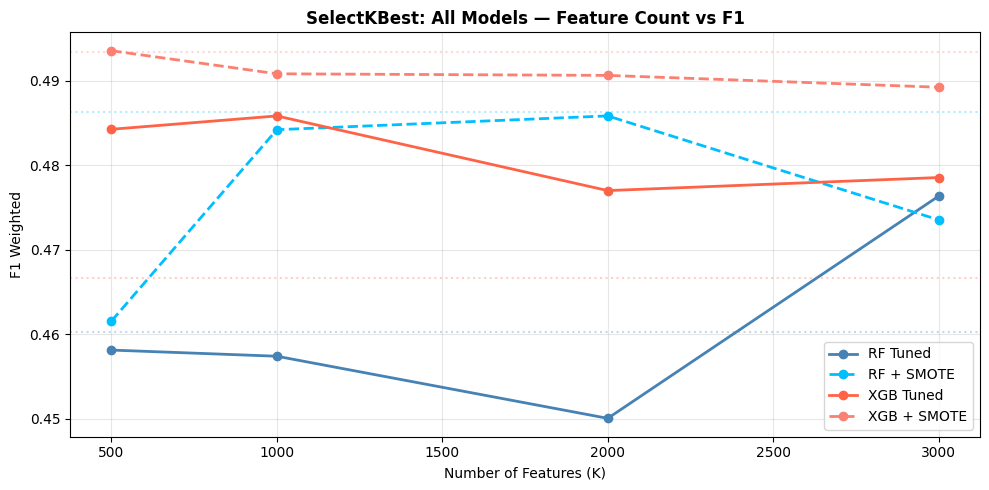


Best K per model:
  RF Tuned       : best K=3000  F1=0.4763  (↑ 0.0161 vs full 9000 features)
  RF + SMOTE     : best K=2000  F1=0.4858  (≈ 0.0004 vs full 9000 features)
  XGB Tuned      : best K=1000  F1=0.4858  (↑ 0.0192 vs full 9000 features)
  XGB + SMOTE    : best K=500  F1=0.4935  (≈ 0.0002 vs full 9000 features)

Global best: XGB + SMOTE with K=500 → F1=0.4935


In [ ]:
# ── Run SelectKBest sweep ──
all_kbest_results = {name: {} for name in models_to_test}

# Selector is fit once per K on X_train_scaled (clean features, not SMOTE)
# SMOTE models then use the SMOTE training data but the same selected columns
for k in k_values:
    selector  = SelectKBest(f_classif, k=k)
    X_tr_kb   = selector.fit_transform(X_train_scaled, y_train)
    X_vl_kb   = selector.transform(X_val_scaled)
    X_tr_sm_kb = selector.transform(X_train_smote)   # SMOTE version of same columns

    print(f'\n── K = {k} ──')
    for name, model in models_to_test.items():
        m = clone(model)
        if name in smote_models:
            m.fit(X_tr_sm_kb, y_train_smote)
        else:
            m.fit(X_tr_kb, y_train)

        y_pred_kb = m.predict(X_vl_kb)
        f1_kb     = f1_score(y_val, y_pred_kb, average='weighted', zero_division=0)
        all_kbest_results[name][k] = f1_kb
        print(f'  {name:<15}: F1 = {f1_kb:.4f}')

# ── Plot all models on one chart ──
colors = ['steelblue', 'deepskyblue', 'tomato', 'salmon', 'seagreen']
linestyles = ['-', '--', '-', '--', ':']

plt.figure(figsize=(10, 5))
for (name, results), color, ls in zip(all_kbest_results.items(), colors, linestyles):
    plt.plot(list(results.keys()), list(results.values()),
             marker='o', color=color, linestyle=ls, linewidth=2, label=name)
    # Draw baseline reference line (full-feature F1) as a faint dot
    plt.axhline(baseline_f1[name], color=color, linestyle=':', alpha=0.3)

plt.xlabel('Number of Features (K)')
plt.ylabel('F1 Weighted')
plt.title('SelectKBest: All Models — Feature Count vs F1', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Per-model best K summary ──
print('\nBest K per model:')
best_k_per_model = {}
for name, results in all_kbest_results.items():
    best_k = max(results, key=results.get)
    best_k_per_model[name] = best_k
    diff = results[best_k] - baseline_f1[name]
    direction = '↑' if diff > 0.001 else ('↓' if diff < -0.001 else '≈')
    print(f'  {name:<15}: best K={best_k}  F1={results[best_k]:.4f}  '
          f'({direction} {abs(diff):.4f} vs full 9000 features)')

# ── Save best selector based on overall winner ──
# Flatten all results and find the globally best (model, K) pair
best_combo = max(
    [(name, k, f1) for name, res in all_kbest_results.items() for k, f1 in res.items()],
    key=lambda x: x[2]
)
print(f'\nGlobal best: {best_combo[0]} with K={best_combo[1]} → F1={best_combo[2]:.4f}')

best_selector = SelectKBest(f_classif, k=best_combo[1])
X_train_kb = best_selector.fit_transform(X_train_scaled, y_train)
X_val_kb   = best_selector.transform(X_val_scaled)
X_test_kb  = best_selector.transform(X_test_scaled)

>The SelectKBest results show that reducing the number of features significantly does not harm performance and can even improve it. The best result is achieved with the XGBoost + SMOTE model using only 500 features, which performs slightly better than using all 9000 features. This indicates that most of the original features are redundant or noisy. XGBoost benefits the most from feature reduction, suggesting it is sensitive to irrelevant features, while Random Forest shows more stable but less pronounced changes. Overall, these results confirm that a smaller feature set (500–1000 features) is sufficient, improving efficiency and potentially reducing overfitting without sacrificing performance.

## 7.3 Applying Feature Selection to Tuned Models


  RF Tuned + K=3000
  Accuracy : 0.4808
  Precision: 0.4970
  Recall   : 0.4808
  F1-score : 0.4763
  AUC-ROC  : 0.5623

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.08      0.17      0.11       114
             Normal       0.64      0.68      0.66       761
       Other rhythm       0.36      0.16      0.22       362
              Noise       0.32      0.52      0.40        42

           accuracy                           0.48      1279
          macro avg       0.35      0.38      0.35      1279
       weighted avg       0.50      0.48      0.48      1279



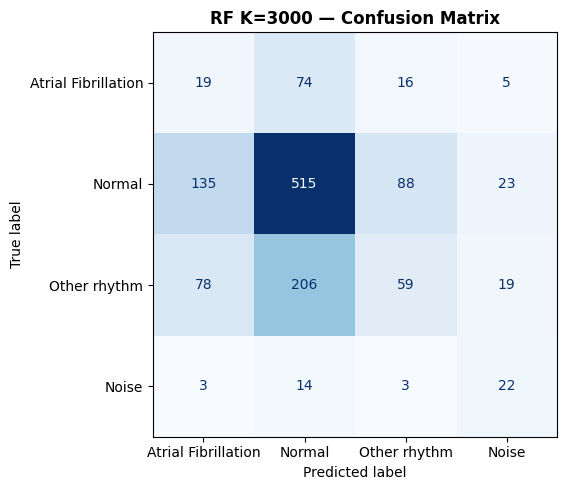

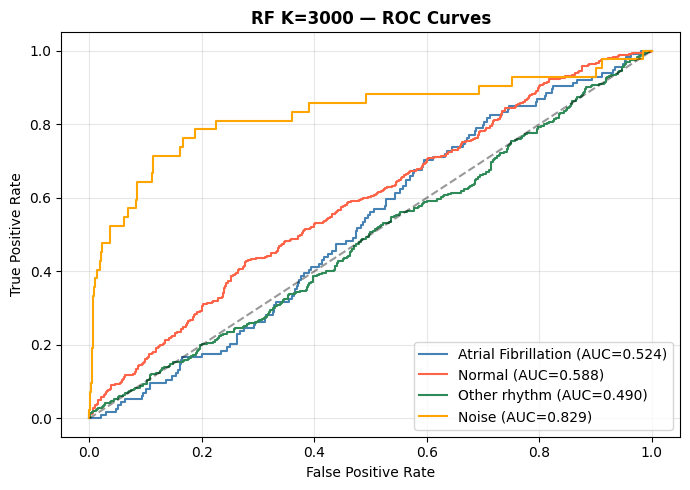

In [ ]:
# 1. Select top features (fit only on training data)
selector_rf = SelectKBest(f_classif, k=3000)

X_train_rf_k = selector_rf.fit_transform(X_train_scaled, y_train)
X_val_rf_k   = selector_rf.transform(X_val_scaled)
X_test_rf_k  = selector_rf.transform(X_test_scaled)

# 2. Define tuned Random Forest
rf_k3000 = RandomForestClassifier(
    n_estimators=350,
    max_depth=10,
    min_samples_leaf=10,
    max_features='log2',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 3. Train model
rf_k3000.fit(X_train_rf_k, y_train)

# 4. Evaluate
y_pred_rf_k  = rf_k3000.predict(X_val_rf_k)
y_proba_rf_k = rf_k3000.predict_proba(X_val_rf_k)

r_rf_k3000 = evaluate_model('RF Tuned + K=3000',y_val,y_pred_rf_k,y_proba_rf_k)
plot_confusion_matrix(y_val, y_pred_rf_k, 'RF K=3000 — Confusion Matrix')
plot_roc_curves(y_val, y_proba_rf_k, 'RF K=3000 — ROC Curves')

> Random Forest with feature selection (K=3000) produces more balanced predictions and improves detection of minority classes, including Atrial Fibrillation and Noise. However, this comes at a significant cost in overall accuracy. In contrast, XGBoost achieves higher accuracy but fails to detect minority classes. This highlights a fundamental trade-off between overall performance and minority class detection.


  XGBoost Tuned + K=500
  Accuracy : 0.5887
  Precision: 0.4748
  Recall   : 0.5887
  F1-score : 0.4842
  AUC-ROC  : 0.5858

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.61      0.94      0.74       761
       Other rhythm       0.37      0.10      0.15       362
              Noise       0.25      0.02      0.04        42

           accuracy                           0.59      1279
          macro avg       0.31      0.27      0.23      1279
       weighted avg       0.47      0.59      0.48      1279



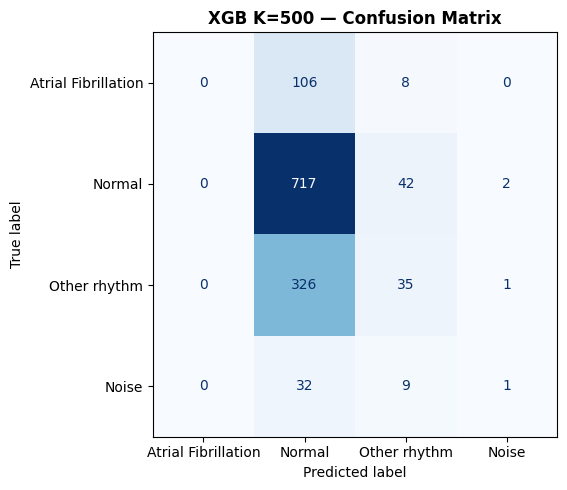

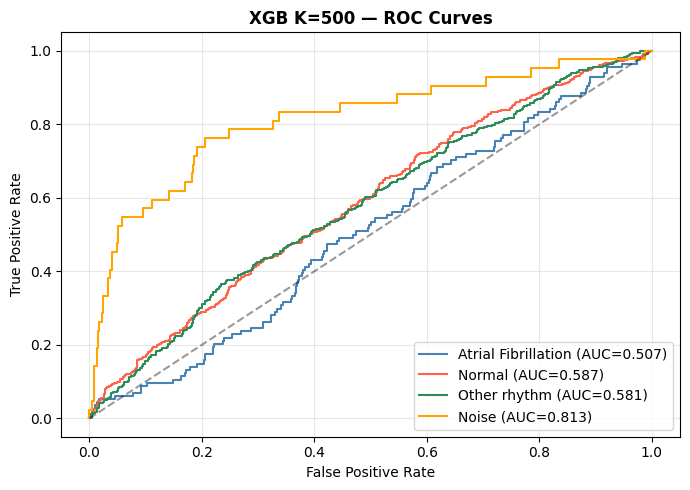

In [ ]:
# 1. Select top 500 features (fit ONLY on training data)
selector = SelectKBest(f_classif, k=500)

X_train_k500 = selector.fit_transform(X_train_scaled, y_train)
X_val_k500   = selector.transform(X_val_scaled)
X_test_k500  = selector.transform(X_test_scaled)

# 2. Define tuned XGBoost model
xgb_k500 = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    tree_method='hist',
    random_state=42,
    eval_metric='mlogloss',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1
)

# 3. Train on reduced features
xgb_k500.fit(X_train_k500, y_train)

# 4. Evaluate on validation set
y_pred_k500  = xgb_k500.predict(X_val_k500)
y_proba_k500 = xgb_k500.predict_proba(X_val_k500)

r_xgb_k500 = evaluate_model('XGBoost Tuned + K=500',y_val,y_pred_k500,y_proba_k500)
plot_confusion_matrix(y_val, y_pred_k500, 'XGB K=500 — Confusion Matrix')
plot_roc_curves(y_val, y_proba_k500, 'XGB K=500 — ROC Curves')

> Applying feature selection (K=500) slightly improved the XGBoost model’s F1-score while significantly reducing dimensionality. However, the model still fails to detect Atrial Fibrillation and performs poorly on minority classes. This confirms that feature selection alone is insufficient to address class imbalance, and additional strategies such as SMOTE or cost-sensitive learning are required.

---
#  8.Final Ensemble — Voting Classifier

> **Why ensemble?**  
Each model has different strengths and makes different types of errors.  
A Voting Classifier combines their predictions — the final class is the majority vote.  
**Soft voting** averages predicted probabilities (more nuanced than hard majority vote).  




> **Strategy:** Combine the top-2 tuned models using **soft voting** (average predicted probabilities).

>
> We build **two** ensembles:
> - **Ensemble A** — plain tuned models (no SMOTE)
> - **Ensemble B** — SMOTE-trained RF + SMOTE-trained XGBoost
> Then compare all variants in a final leaderboard.

Training final Soft Voting Ensemble...

  Soft Voting Ensemble
  Accuracy : 0.5958
  Precision: 0.4962
  Recall   : 0.5958
  F1-score : 0.4719
  AUC-ROC  : 0.5882

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       114
             Normal       0.60      0.97      0.74       761
       Other rhythm       0.42      0.04      0.08       362
              Noise       0.64      0.17      0.26        42

           accuracy                           0.60      1279
          macro avg       0.41      0.30      0.27      1279
       weighted avg       0.50      0.60      0.47      1279



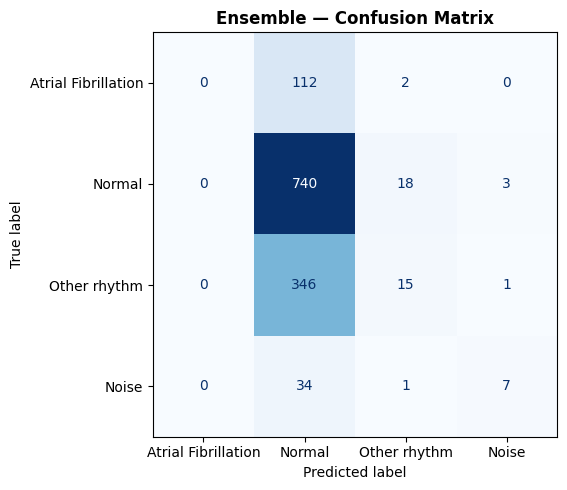

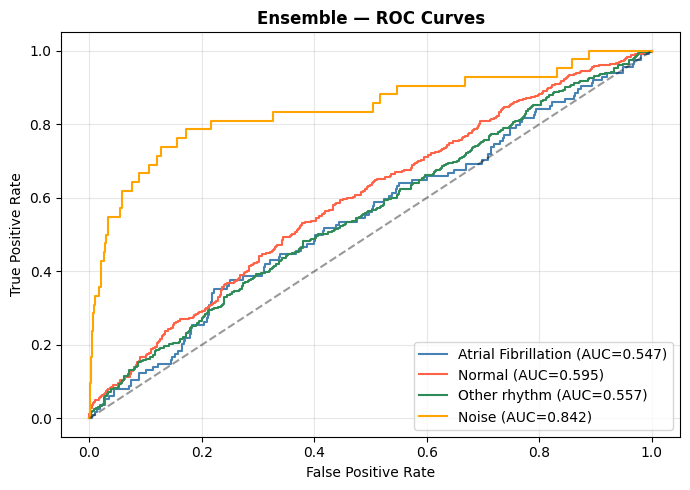

In [ ]:
ensemble_a = VotingClassifier(
    estimators=[
        ('rf', rf_tuned),
        ('xgb', xgb_tuned),
    ],
    voting='soft'
)
print('Training final Soft Voting Ensemble...')
ensemble_a.fit(X_train, y_train)

y_pred_ens_a  = ensemble_a.predict(X_val)
y_proba_ens_a = ensemble_a.predict_proba(X_val)

r_ens_a = evaluate_model('Soft Voting Ensemble', y_val, y_pred_ens_a, y_proba_ens_a)
plot_confusion_matrix(y_val, y_pred_ens_a, 'Ensemble — Confusion Matrix')
plot_roc_curves(y_val, y_proba_ens_a, 'Ensemble — ROC Curves')

> The Soft Voting Ensemble (RF + XGBoost, clean data) achieves the highest overall accuracy, primarily due to strong performance on the majority Normal class. However, it completely fails to detect Atrial Fibrillation and performs poorly on Other rhythm and Noise. This indicates that the ensemble inherits the class imbalance bias from its base models. Although ROC curves suggest some separability, the model’s decision threshold heavily favors the Normal class. Overall, despite good accuracy, this model is not suitable for imbalanced medical classification where minority class detection is critical.

In [ ]:
def soft_vote_predict_proba(models, X):
    probas = np.stack([m.predict_proba(X) for m in models], axis=0)
    return probas.mean(axis=0)

Evaluating Manual Ensemble (SMOTE)...

  Manual Ensemble (SMOTE)
  Accuracy : 0.5661
  Precision: 0.4841
  Recall   : 0.5661
  F1-score : 0.4919
  AUC-ROC  : 0.5774

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.07      0.01      0.02       114
             Normal       0.61      0.87      0.71       761
       Other rhythm       0.35      0.16      0.22       362
              Noise       0.60      0.07      0.13        42

           accuracy                           0.57      1279
          macro avg       0.41      0.28      0.27      1279
       weighted avg       0.48      0.57      0.49      1279



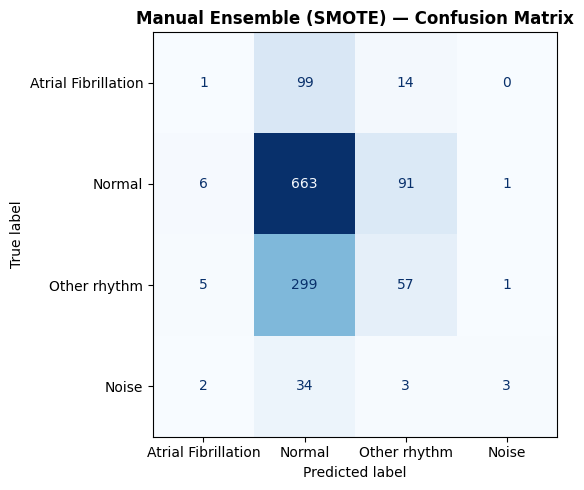

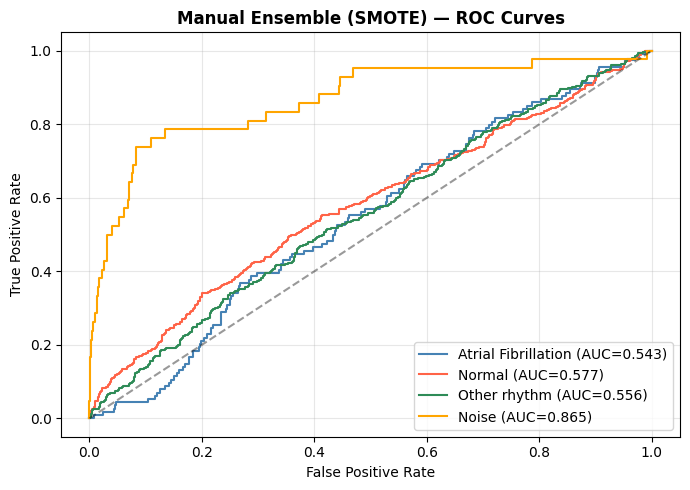

In [ ]:
models_smote_ens = [rf_smote, xgb_smote]

print("Evaluating Manual Ensemble (SMOTE)...")
y_proba_manual_smote = soft_vote_predict_proba(models_smote_ens, X_val_scaled)
y_pred_manual_smote  = np.argmax(y_proba_manual_smote, axis=1)

r_manual_smote = evaluate_model('Manual Ensemble (SMOTE)', y_val, y_pred_manual_smote, y_proba_manual_smote)
plot_confusion_matrix(y_val, y_pred_manual_smote, 'Manual Ensemble (SMOTE) — Confusion Matrix')
plot_roc_curves(y_val, y_proba_manual_smote, 'Manual Ensemble (SMOTE) — ROC Curves')

>The Manual Ensemble (SMOTE) improves performance over the clean ensemble by increasing the weighted F1-score and enhancing detection of minority classes, particularly Other rhythm. This comes at the cost of reduced accuracy due to less emphasis on the majority Normal class. While SMOTE helps the model become more sensitive to underrepresented classes, Atrial Fibrillation detection remains extremely low, indicating that class imbalance is not the only challenge. Overall, the SMOTE-based ensemble provides a more balanced model but still struggles with clinically important minority classes.

## 8.1 Ensemble vs Single Best Model — Comparison

In [ ]:
leaderboard_rows = [
    # ── single tuned models ───────────────────────────────────────────────
    {'name': 'RF Tuned',               'type': 'Single',**{k: v for k, v in r_rf_tuned.items()     if k != 'name'}},
    {'name': 'XGBoost Tuned',          'type': 'Single',**{k: v for k, v in r_xgb_tuned.items()    if k != 'name'}},
    {'name': 'RF + SMOTE',             'type': 'Single',**{k: v for k, v in r_rf_smote.items()     if k != 'name'}},
    {'name': 'XGBoost + SMOTE',        'type': 'Single',**{k: v for k, v in r_xgb_smote.items()    if k != 'name'}},
    # ── ensemble variants ─────────────────────────────────────────────────
    {'name': 'Ensemble A (clean)',      'type': 'Ensemble',**{k: v for k, v in r_ens_a.items()        if k != 'name'}},
    {'name': 'Ensemble B (SMOTE)',      'type': 'Ensemble',**{k: v for k, v in r_manual_smote.items() if k != 'name'}},
]

df_leaderboard = pd.DataFrame(leaderboard_rows)\
                   .sort_values('f1', ascending=False)\
                   .reset_index(drop=True)
df_leaderboard.insert(0, 'Rank', range(1, len(df_leaderboard) + 1))

print("=" * 78)
print("   FINAL LEADERBOARD — Tuned Singles vs Ensemble ")
print("=" * 78)
print(df_leaderboard[['Rank','name','type','accuracy','precision','recall','f1','auc']]
      .to_string(index=False))

   FINAL LEADERBOARD — Tuned Singles vs Ensemble 
 Rank               name     type  accuracy  precision   recall       f1      auc
    1    XGBoost + SMOTE   Single  0.567631   0.478226 0.567631 0.493361 0.577365
    2 Ensemble B (SMOTE) Ensemble  0.566067   0.484103 0.566067 0.491899 0.577430
    3         RF + SMOTE   Single  0.523065   0.473248 0.523065 0.486225 0.559956
    4 Ensemble A (clean) Ensemble  0.595778   0.496212 0.595778 0.471852 0.588211
    5      XGBoost Tuned   Single  0.593432   0.493766 0.593432 0.466639 0.585857
    6           RF Tuned   Single  0.456607   0.482470 0.456607 0.460252 0.559745


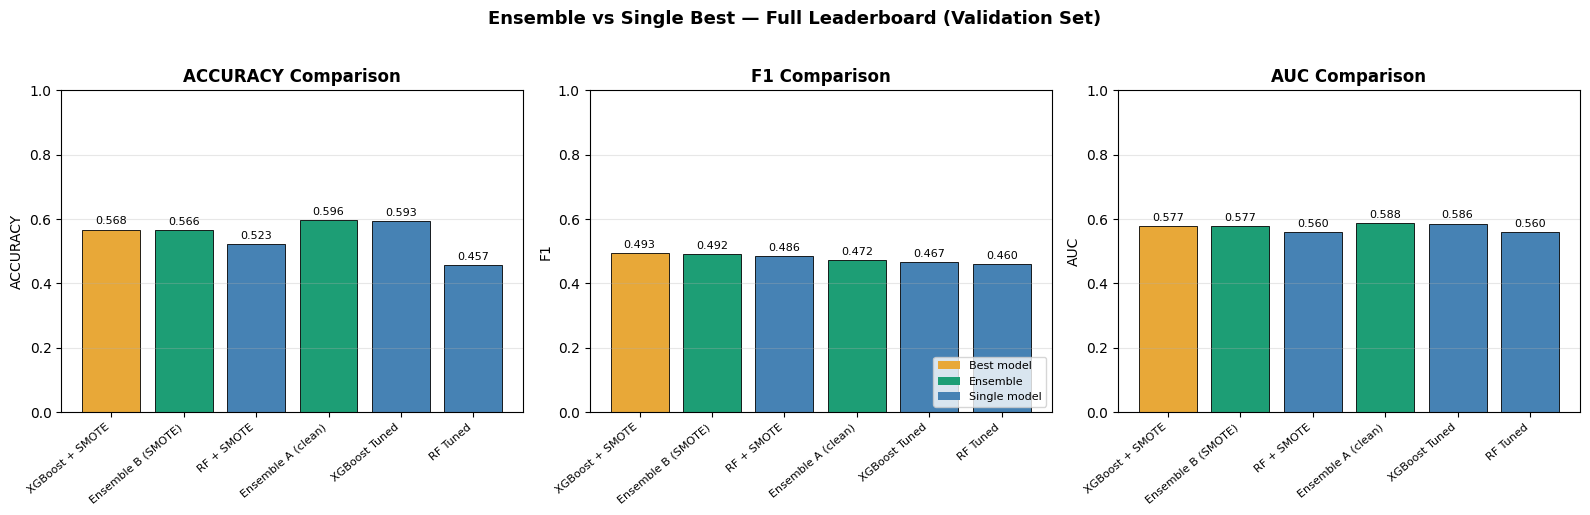

In [ ]:
# ── Bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

best_model = df_leaderboard.iloc[0]['name']

bar_colors = []
for _, row in df_leaderboard.iterrows():
    if row['name'] == best_model:
        bar_colors.append('#E8A838')   # gold — winner
    elif 'Ensemble' in row['name']:
        bar_colors.append('#1D9E75')   # green — ensembles
    else:
        bar_colors.append('steelblue') # blue — single models

for ax, metric in zip(axes, ['accuracy', 'f1', 'auc']):
    bars = ax.bar(df_leaderboard['name'], df_leaderboard[metric],
                  color=bar_colors, edgecolor='black', linewidth=0.6)
    ax.set_ylabel(metric.upper())
    ax.set_title(f"{metric.upper()} Comparison", fontweight='bold')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', labelrotation=40, labelsize=8)
    for label in ax.get_xticklabels():
        label.set_ha('right')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_leaderboard[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f"{val:.3f}", ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='#E8A838', label='Best model'),
    Patch(facecolor='#1D9E75',   label='Ensemble'),
    Patch(facecolor='steelblue', label='Single model'),
]
axes[1].legend(handles=legend_handles, loc='lower right', fontsize=8)
plt.suptitle("Ensemble vs Single Best — Full Leaderboard (Validation Set)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> The final leaderboard shows that the best-performing model is XGBoost + SMOTE, achieving the highest weighted F1-score. Although ensemble methods were explored, including both clean and SMOTE-based voting strategies, they did not outperform the best single model. Ensemble B (SMOTE) achieved similar performance but did not provide a meaningful improvement. This suggests that the primary performance gain comes from handling class imbalance (via SMOTE) rather than model combination. Therefore, the tuned XGBoost + SMOTE model is selected as the final model.

---
#  9.Final Evaluation on Test Set

> **Why evaluate on the test set only now?**  
The test set was never used during training or tuning — it simulates truly unseen data.  
Using it earlier would cause optimistic results (data snooping bias).  


   PHASE 5 — FINAL TEST SET EVALUATION (run once)

  XGBoost Baseline (Clean) — TEST
  Accuracy : 0.5934
  Precision: 0.5707
  Recall   : 0.5934
  F1-score : 0.4632
  AUC-ROC  : 0.5902

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       1.00      0.01      0.02       113
             Normal       0.60      0.98      0.74       761
       Other rhythm       0.32      0.03      0.06       363
              Noise       1.00      0.02      0.05        42

           accuracy                           0.59      1279
          macro avg       0.73      0.26      0.22      1279
       weighted avg       0.57      0.59      0.46      1279



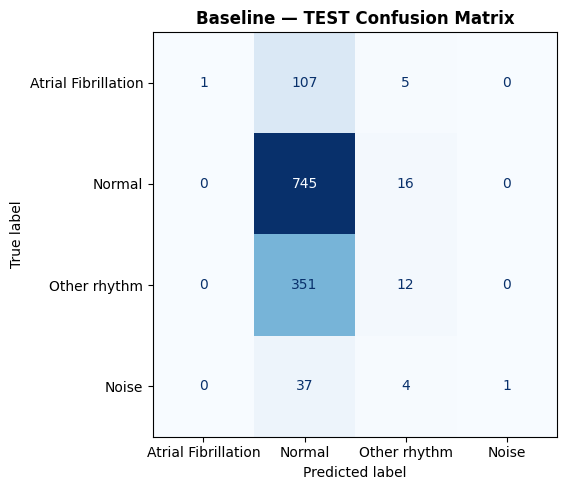

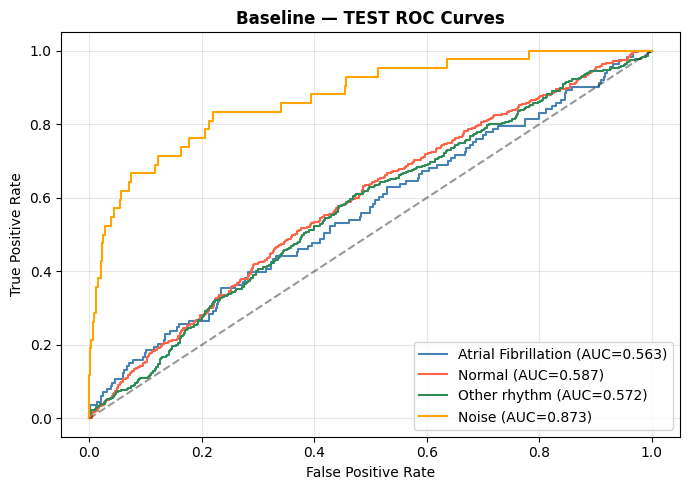


  XGBoost Tuned (Clean) — TEST
  Accuracy : 0.5942
  Precision: 0.4743
  Recall   : 0.5942
  F1-score : 0.4608
  AUC-ROC  : 0.5845

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       113
             Normal       0.60      0.98      0.75       761
       Other rhythm       0.35      0.03      0.06       363
              Noise       0.50      0.02      0.05        42

           accuracy                           0.59      1279
          macro avg       0.36      0.26      0.21      1279
       weighted avg       0.47      0.59      0.46      1279



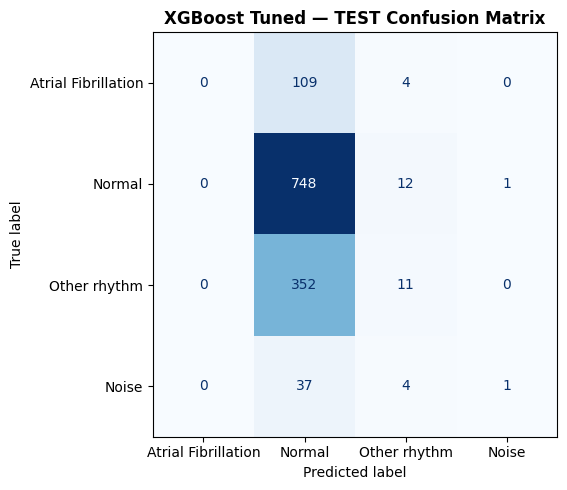

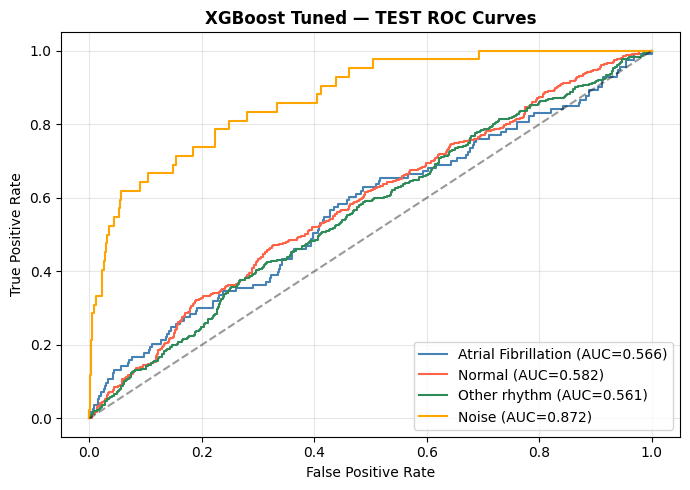


  XGBoost Adversarial (10% Noise) — TEST
  Accuracy : 0.5958
  Precision: 0.5062
  Recall   : 0.5958
  F1-score : 0.4711
  AUC-ROC  : 0.5593

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.00      0.00      0.00       113
             Normal       0.60      0.98      0.74       761
       Other rhythm       0.40      0.05      0.09       363
              Noise       1.00      0.02      0.05        42

           accuracy                           0.60      1279
          macro avg       0.50      0.26      0.22      1279
       weighted avg       0.51      0.60      0.47      1279



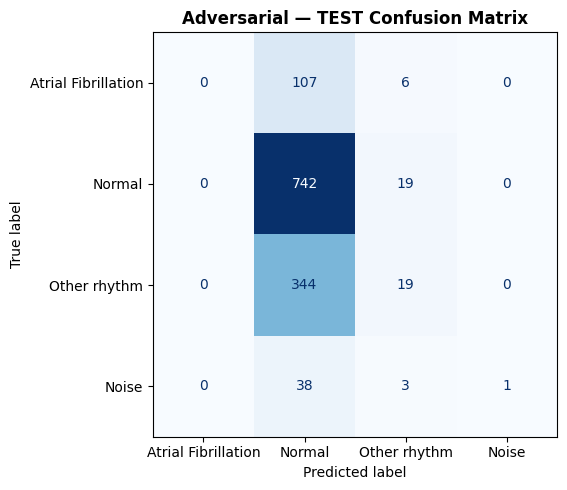

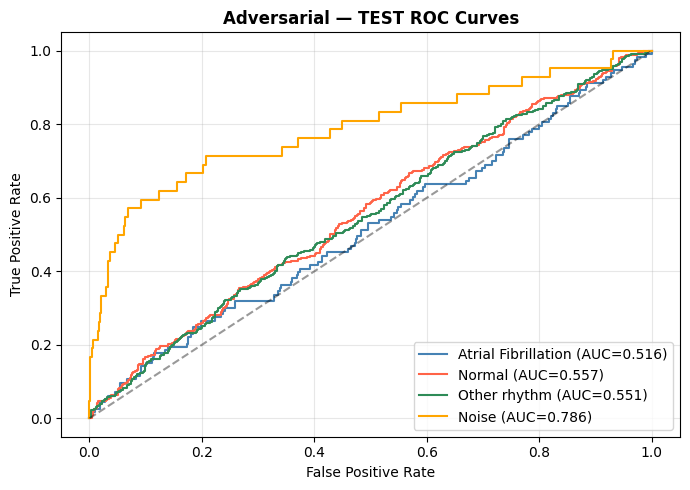


  XGBoost Tuned + SMOTE (Best) — TEST
  Accuracy : 0.5567
  Precision: 0.4725
  Recall   : 0.5567
  F1-score : 0.4844
  AUC-ROC  : 0.5802

Classification Report:
                     precision    recall  f1-score   support

Atrial Fibrillation       0.17      0.02      0.03       113
             Normal       0.60      0.86      0.71       761
       Other rhythm       0.31      0.15      0.20       363
              Noise       0.33      0.05      0.08        42

           accuracy                           0.56      1279
          macro avg       0.35      0.27      0.26      1279
       weighted avg       0.47      0.56      0.48      1279



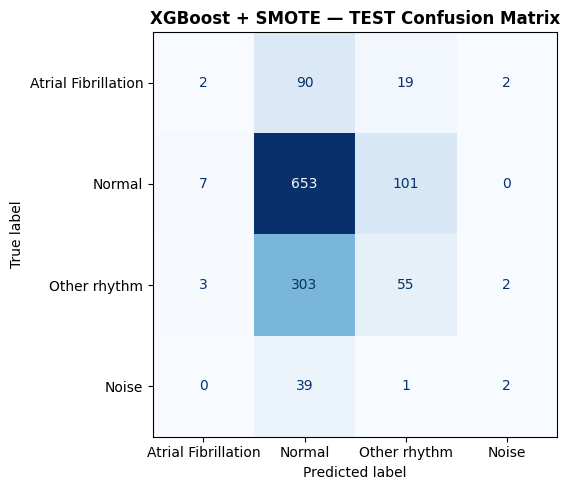

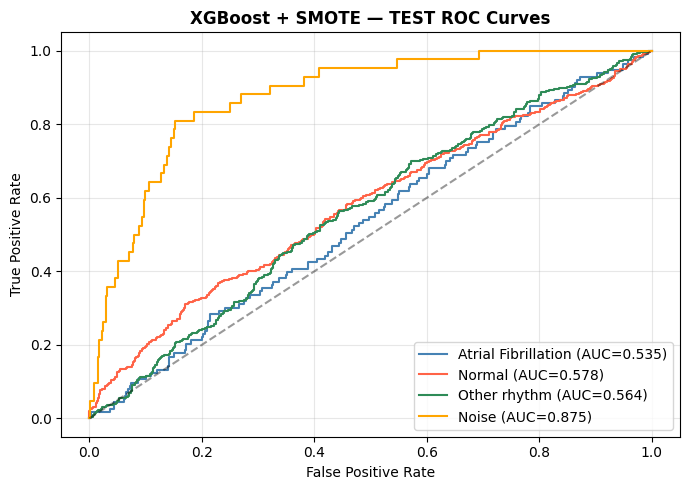

In [ ]:
print("=" * 65)
print("   PHASE 5 — FINAL TEST SET EVALUATION (run once)")
print("=" * 65)

# ── 1. Baseline ────────────────────────────────────────────────────────
y_pred_base_test  = xgb_clean.predict(X_test_scaled)
y_proba_base_test = xgb_clean.predict_proba(X_test_scaled)

r_base_test = evaluate_model('XGBoost Baseline (Clean) — TEST', y_test, y_pred_base_test, y_proba_base_test)
plot_confusion_matrix(y_test, y_pred_base_test,'Baseline — TEST Confusion Matrix')
plot_roc_curves(y_test, y_proba_base_test,'Baseline — TEST ROC Curves')

# ── 2. Tuned (no SMOTE) ───────────────────────────────────────────────
y_pred_tuned_test  = xgb_tuned.predict(X_test)
y_proba_tuned_test = xgb_tuned.predict_proba(X_test)

r_tuned_test = evaluate_model('XGBoost Tuned (Clean) — TEST',y_test, y_pred_tuned_test, y_proba_tuned_test)
plot_confusion_matrix(y_test, y_pred_tuned_test,'XGBoost Tuned — TEST Confusion Matrix')
plot_roc_curves(y_test, y_proba_tuned_test,'XGBoost Tuned — TEST ROC Curves')

# ── 3. Adversarial condition model ────────────────────────────────────
y_pred_adv_test  = xgb_noisy.predict(X_test_scaled)
y_proba_adv_test = xgb_noisy.predict_proba(X_test_scaled)

r_adv_test = evaluate_model('XGBoost Adversarial (10% Noise) — TEST',y_test, y_pred_adv_test, y_proba_adv_test)
plot_confusion_matrix(y_test, y_pred_adv_test,'Adversarial — TEST Confusion Matrix')
plot_roc_curves(y_test, y_proba_adv_test,'Adversarial — TEST ROC Curves')

# ── 4. Final Best Model ───────────────────────────────────────────────
y_pred_best_test  = xgb_smote.predict(X_test_scaled)
y_proba_best_test = xgb_smote.predict_proba(X_test_scaled)

r_best_test = evaluate_model('XGBoost Tuned + SMOTE (Best) — TEST',y_test, y_pred_best_test, y_proba_best_test)
plot_confusion_matrix(y_test, y_pred_best_test,'XGBoost + SMOTE — TEST Confusion Matrix')
plot_roc_curves(y_test, y_proba_best_test,'XGBoost + SMOTE — TEST ROC Curves')

### Final Evaluation on Test Set

The final evaluation was conducted on a held-out test set using four models: a baseline XGBoost model, a tuned XGBoost model, an adversarial (noisy) XGBoost model, and a SMOTE-enhanced XGBoost model.

> Results Summary

| Model                   | Accuracy | Precision | Recall | F1-score  | AUC   |
| ----------------------- | -------- | --------- | ------ | --------- | ----- |
| Baseline (xgb_clean)    | 0.593    | 0.571     | 0.593  | 0.463     | 0.590 |
| Tuned (xgb_tuned)       | 0.594    | 0.474     | 0.594  | 0.461     | 0.585 |
| Adversarial (xgb_noisy) | 0.596    | 0.506     | 0.596  | 0.471     | 0.559 |
| **Best (xgb_smote)**  | 0.557    | 0.472     | 0.557  | **0.484** | 0.580 |


> F1 Improvement vs Baseline

| Model              | Change in F1 |
| ------------------ | ------------ |
| Tuned              | −0.002       |
| Adversarial        | +0.008       |
| **Best (SMOTE)**  | **+0.021**   |



> Interpretation
The SMOTE-based model achieves the highest F1-score (0.484), making it the best overall model. Although it has lower accuracy, it provides a better balance between precision and recall, which is more appropriate for imbalanced data.
In contrast, the baseline and tuned models achieve higher accuracy but fail to detect minority classes, particularly Atrial Fibrillation, due to strong bias toward the Normal class. The adversarial model shows only a small improvement and reduced reliability, as indicated by a lower AUC.


> Per-Class Performance Analysis:

To better understand model behavior, per-class F1-scores were examined on the test set:

| Class               | Baseline| Tuned | Adversarial | Best (SMOTE) |
| ------------------- | --------| ----- | ----------- | ------------ |
| Atrial Fibrillation | 0.02    | 0.00  | 0.00        | **0.03**     |
| Normal              | 0.74    | 0.75  | 0.74        | 0.71         |
| Other rhythm        | 0.06    | 0.06  | 0.09        | **0.20**     |
| Noise               | 0.05    | 0.05  | 0.05        | **0.08**     |
| **Weighted avg**    | 0.46    | 0.46  | 0.47        | **0.48**     |


> Interpretation:
All models perform well on the Normal class, confirming strong class imbalance bias.
Atrial Fibrillation is poorly detected across all models, including the best model, highlighting a major limitation.
The SMOTE model improves detection of Other rhythm and Noise, which explains its higher overall F1-score, but this comes with a slight reduction in Normal class performance.

> Adversarial Degradation Analysis

To assess robustness, the effect of adversarial label noise (10%) was analyzed:

| Class               | Baseline F1 | Adversarial F1 | Change   |
| ------------------- | ----------- | -------------- | -------- |
| Atrial Fibrillation | 0.02        | 0.00           | ↓ −0.02  |
| Normal              | 0.74        | 0.74           | ≈ 0.00   |
| Other rhythm        | 0.06        | 0.09           | ↑ +0.03  |
| Noise               | 0.05        | 0.05           | ≈ 0.00   |
| **Weighted avg**    | 0.46        | 0.47           | ↑ +0.01  |



>Interpretation:
Adversarial noise has a mixed effect: performance on the Normal class remains stable, while Atrial Fibrillation detection worsens further. Other rhythm shows slight improvement, suggesting a mild regularization effect. However, the overall gain is small and accompanied by reduced AUC, indicating weaker model reliability.


### Honest Limitations Analysis

>What Failed

The primary limitation of this project is the inability to reliably detect Atrial Fibrillation (AF). Even the best model achieves a very low F1-score (~0.03), which is insufficient for a clinically important class.

This issue is largely due to the use of raw 9000-point signals as input features, which do not explicitly capture key AF characteristics such as irregular rhythm patterns. As a result, the model struggles to distinguish AF from other classes.

Additionally, SMOTE was not effective for AF. While it improved performance for other minority classes, it likely generated unrealistic synthetic AF samples, limiting its ability to improve AF detection.

>What Could Be Improved

A more effective approach would involve using domain-specific ECG features instead of raw signals. Examples include:

Heart rate variability (RR intervals)
Signal morphology (P-wave, QRS complex)
Frequency-domain features

These features directly represent clinically meaningful patterns and would make classification more learnable.

Feature selection experiments demonstrated that a reduced feature set (e.g., K=500) can maintain similar performance to the full 9000 features, but without meaningful improvement. This suggests that the limitation lies not in feature quantity, but in the lack of informative signal representation.

>Why Performance Degrades Under Adversarial Conditions

The adversarial setup (10% label noise) disproportionately affects minority classes:

The Normal class remains stable due to its large sample size
Minority classes, especially AF, are highly sensitive to noise

This increases model bias toward the majority class and further degrades AF detection.

Interestingly, adversarial noise produced a small increase in overall F1-score, likely due to a mild regularization effect, but this came at the cost of reduced AUC, indicating weaker class separability.

>Key Takeaway

The main limitation is not the model choice, but the combination of class imbalance and inadequate feature representation. Without features that capture the underlying structure of ECG signals, even well-tuned models cannot reliably detect clinically important minority classes.

---
# 10.Project Summary & Conclusions

## Summary of the Full Pipeline

| Phase                 | What We Did                                                  | Key Result                                               |
| --------------------- | ------------------------------------------------------------ | -------------------------------------------------------- |
| **EDA**               | Explored signals, class distribution, duplicates             | Severe class imbalance; Normal dominant                  |
| **Preprocessing**     | Resampled to 9000pts, encoded labels, 70/15/15 split, scaled | Clean, leak-free dataset                                 |
| **Adversarial**       | Injected 10% label noise                                     | Slight F1 increase, but lower AUC and worse AF detection |
| **Baselines**         | Evaluated multiple classifiers                               | RF and XGBoost performed best                            |
| **Tuning**            | Hyperparameter tuning for RF and XGBoost                     | Improvement; imbalance remained                  |
| **Imbalance**         | Applied SMOTE                                                | XGBoost + SMOTE achieved highest F1                      |
| **Feature Selection** | SelectKBest (K=500–3000)                                     | Reduced features maintained performance                  |
| **Ensemble**          | Soft Voting (RF + XGB)                                       | No improvement over best model                           |
| **Final Evaluation**  | Tested models on held-out test set                           | Best F1 ≈ 0.484; AF detection remained very low          |


## Key Findings

**1. Class imbalance is the central challenge.**  
Accuracy is misleading — models can achieve high accuracy by predicting the Normal class.
F1-score and per-class recall are more informative.

**2. XGBoost performed best overall.**  
It consistently outperformed other models, especially when combined with imbalance handling.

**3. SMOTE improves minority classes, but not Atrial Fibrillation.**  
It improves Other rhythm and Noise, but AF detection remains extremely poor..

**4.Feature selection improves efficiency, not performance.**  
Reducing to fewer features maintained similar results, indicating redundancy in raw signals.

**5. Adversarial noise has a mixed effect.**  
It slightly improves F1 but reduces AUC and worsens AF detection, lowering reliability.
